# Machine Learning for Cosmological Parameter Inference

## Controlled Experiments for Predicting $\Omega_m$ from CAMELS-SIMBA Halo Graphs

**Bachelor Thesis · Final experiment report**  
Generated: **2026-07-30** · Branch: **`thesis-controlled-scaling`** · Commit: **`56c348cb4584`**

All results in this report are precomputed, verified, and reproduced from
committed analysis packages. No training, graph-dataset loading, or checkpoint
loading is performed.

<div class="callout">
<b>Executive summary.</b> This thesis tests EvolveGCN-H and Static GCN for
regressing the matter-density parameter from halo catalogues. The recurring
challenge is prediction compression toward the target mean. Six finalized
controlled analyses show that additional halos and preserving absolute feature
scales help under specific protocols, whereas changing k, hidden width, head
complexity, or naïvely appending max pooling does not close the remaining gap.
</div>

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "configs").is_dir() and (candidate / "reports/analysis").is_dir():
            return candidate
    raise RuntimeError("Repository root could not be located.")

ROOT = find_repo_root()
PACKAGE_NAMES = {
    "universe": "controlled_static_vs_evolvegcn_universe_scaling_top100",
    "topn": "controlled_static_vs_evolvegcn_topn_halo_scaling_500u",
    "normalization": "controlled_static_vs_evolvegcn_normalization_ablation_500u_top500",
    "knn_h64": "controlled_static_vs_evolvegcn_knn_ablation_500u_top100_h64",
    "factorial": "controlled_knn_by_hidden_dim_factorial_500u_top100",
    "head": "controlled_evolvegcn_regression_head_ablation_750u_top1000",
    "pooling": "controlled_evolvegcn_graph_pooling_ablation_750u_top1000",
}
PACKAGES = {key: ROOT / "reports/analysis" / name for key, name in PACKAGE_NAMES.items()}
MANIFESTS = {
    key: json.loads((path / "analysis_manifest.json").read_text(encoding="utf-8"))
    for key, path in PACKAGES.items()
}

def read_csv(key, relative):
    path = PACKAGES[key] / relative
    if not path.is_file():
        raise FileNotFoundError(f"Required table is missing: {path}")
    return pd.read_csv(path)

def read_markdown(key, relative):
    path = PACKAGES[key] / relative
    if not path.is_file():
        raise FileNotFoundError(f"Required Markdown source is missing: {path}")
    return path.read_text(encoding="utf-8")

def figure_path(key, name):
    package = PACKAGES[key]
    path = package / "figures" / f"{name}.png"
    relative = f"figures/{name}.png"
    manifest = MANIFESTS[key]
    listed = set(manifest.get("generated_outputs", ()))
    named = set(manifest.get("generated_figures", ()))
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(f"Required figure is missing: {path}")
    if listed and relative not in listed and name not in named:
        raise RuntimeError(f"Figure is not registered by the finalized manifest: {relative}")
    return path

def show_table(frame, columns=None, rename=None, precision=4, caption=None):
    table = frame.copy()
    if columns is not None:
        table = table.loc[:, columns]
    if rename:
        table = table.rename(columns=rename)
    styler = (
        table.style
        .hide(axis="index")
        .format(precision=precision, na_rep="—")
        .set_table_attributes('class="dataframe presentation-table"')
    )
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

def show_figures(items, width=720):
    for key, name, caption in items:
        display(Image(filename=str(figure_path(key, name)), width=width))
        display(HTML(f'<div class="figure-caption">{caption}</div>'))

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [2]:
display(HTML(r'''
<style>
.jp-Notebook, .container { max-width: 1180px !important; margin: auto; }
body { color: #17202a; line-height: 1.52; }
h1 { color: #17365d; margin-top: 1.1em; border-bottom: 2px solid #d7e3f2; padding-bottom: .2em; }
h2 { color: #244f78; margin-top: 1.25em; }
h3 { color: #35658d; margin-top: 1em; }
.callout { border-left: 5px solid #2f6f9f; background: #edf5fb; padding: 12px 16px; margin: 14px 0; border-radius: 3px; }
.takeaway { border-left: 5px solid #3b7d44; background: #eff8f0; padding: 12px 16px; margin: 14px 0; border-radius: 3px; }
.caveat { border-left: 5px solid #b57b15; background: #fff8e8; padding: 12px 16px; margin: 14px 0; border-radius: 3px; }
.figure-caption { text-align: center; color: #52616b; font-size: .88em; margin: -6px 0 18px; }
table.presentation-table { font-size: .86em; width: 100%; }
table.presentation-table caption { caption-side: top; text-align: left; font-weight: 600; color: #244f78; padding: 6px 0; }
details { background: #f7f8fa; padding: 8px 12px; margin: 10px 0 18px; border-radius: 4px; }
summary { cursor: pointer; font-weight: 600; color: #35566f; }
img { display: block; margin-left: auto; margin-right: auto; }
@media print { h1, h2 { page-break-after: avoid; } .takeaway, .callout, .caveat, table, img { page-break-inside: avoid; } }
</style>
'''))

# 1 — Research Question

$\Omega_m$ is the fraction of the cosmic energy budget associated with matter.
Inferring it from halo catalogues tests whether the abundance, mass,
phase-space distribution, and relational structure of dark-matter halos retain
recoverable cosmological information.

Graphs are natural because halos are entities with features and spatial
relationships. Simple baselines remain essential: they reveal whether signal
exists in explicit distributional summaries even when a graph encoder does
not extract it effectively.

> **Central thesis question:** Can graph-based models recover cosmological
> information from the distribution, dynamics, and structure of dark-matter
> halos, and why do the tested GNNs struggle to outperform summary-feature
> baselines?

# 2 — Data and Graph Representation

In [3]:
data_design = pd.DataFrame([
    ("Simulation suite", "CAMELS-SIMBA"),
    ("Target", "Omega_m (scalar per universe)"),
    ("Universe", "One independent simulated cosmology"),
    ("Snapshot", "One cosmic-time halo catalogue"),
    ("Graph node", "One retained halo"),
    ("Node features", "log10(Mvir), X, Y, Z, VX, VY, VZ"),
    ("Periodic box", "25 h^-1 Mpc"),
    ("Edges", "Periodic-boundary-aware k-nearest neighbours"),
    ("Top-N", "N most massive valid halos by raw Mvir, per universe/snapshot"),
    ("Evolve input", "Temporal graph sequence"),
    ("Static input", "Final-snapshot graph"),
], columns=["Concept", "Meaning"])
show_table(data_design, caption="Core data and graph representation")

Concept,Meaning
Simulation suite,CAMELS-SIMBA
Target,Omega_m (scalar per universe)
Universe,One independent simulated cosmology
Snapshot,One cosmic-time halo catalogue
Graph node,One retained halo
Node features,"log10(Mvir), X, Y, Z, VX, VY, VZ"
Periodic box,25 h^-1 Mpc
Edges,Periodic-boundary-aware k-nearest neighbours
Top-N,"N most massive valid halos by raw Mvir, per universe/snapshot"
Evolve input,Temporal graph sequence


`U500`, `Top500`, and `k=8` are different quantities: 500 independent
universes, at most 500 retained halos per universe and snapshot, and eight
nearest-neighbour selections per real node.

**Pipeline**

Halo catalogues → raw-Mvir Top-N selection → periodic kNN graphs →
EvolveGCN-H or Static GCN → graph readout → temporal readout where applicable
→ regression head → $\Omega_m$

# 3 — Models

In [4]:
models = pd.DataFrame([
    ("EvolveGCN-H", "Temporal graph sequence", "Graph-convolution parameters evolve over snapshots", "Per-snapshot graph pooling", "Temporal pooling", "Scalar head"),
    ("Static GCN", "Final snapshot", "Fixed graph-convolution stack", "Graph pooling", "Not applicable", "Fixed MLP readout"),
], columns=["Model", "Input", "Encoder", "Graph readout", "Temporal readout", "Regression"])
show_table(models, caption="Model protocols; cross-model comparisons are descriptive unless every setting is matched")

Model,Input,Encoder,Graph readout,Temporal readout,Regression
EvolveGCN-H,Temporal graph sequence,Graph-convolution parameters evolve over snapshots,Per-snapshot graph pooling,Temporal pooling,Scalar head
Static GCN,Final snapshot,Fixed graph-convolution stack,Graph pooling,Not applicable,Fixed MLP readout


The model families differ in temporal input, layer count, batch size, and
regression architecture. Their within-model ablations are controlled;
Static-versus-Evolve comparisons describe complete protocols rather than
isolating temporal processing.

# 4 — Why Prediction Collapse Matters

Regression can appear numerically stable while producing predictions clustered
near the test-target mean. A prediction-SD/target-SD ratio below one indicates
compressed dispersion. Exact repeated-prediction fractions expose stronger
degeneracy. MAE alone cannot show whether the model distinguishes low- and
high-$\Omega_m$ universes.

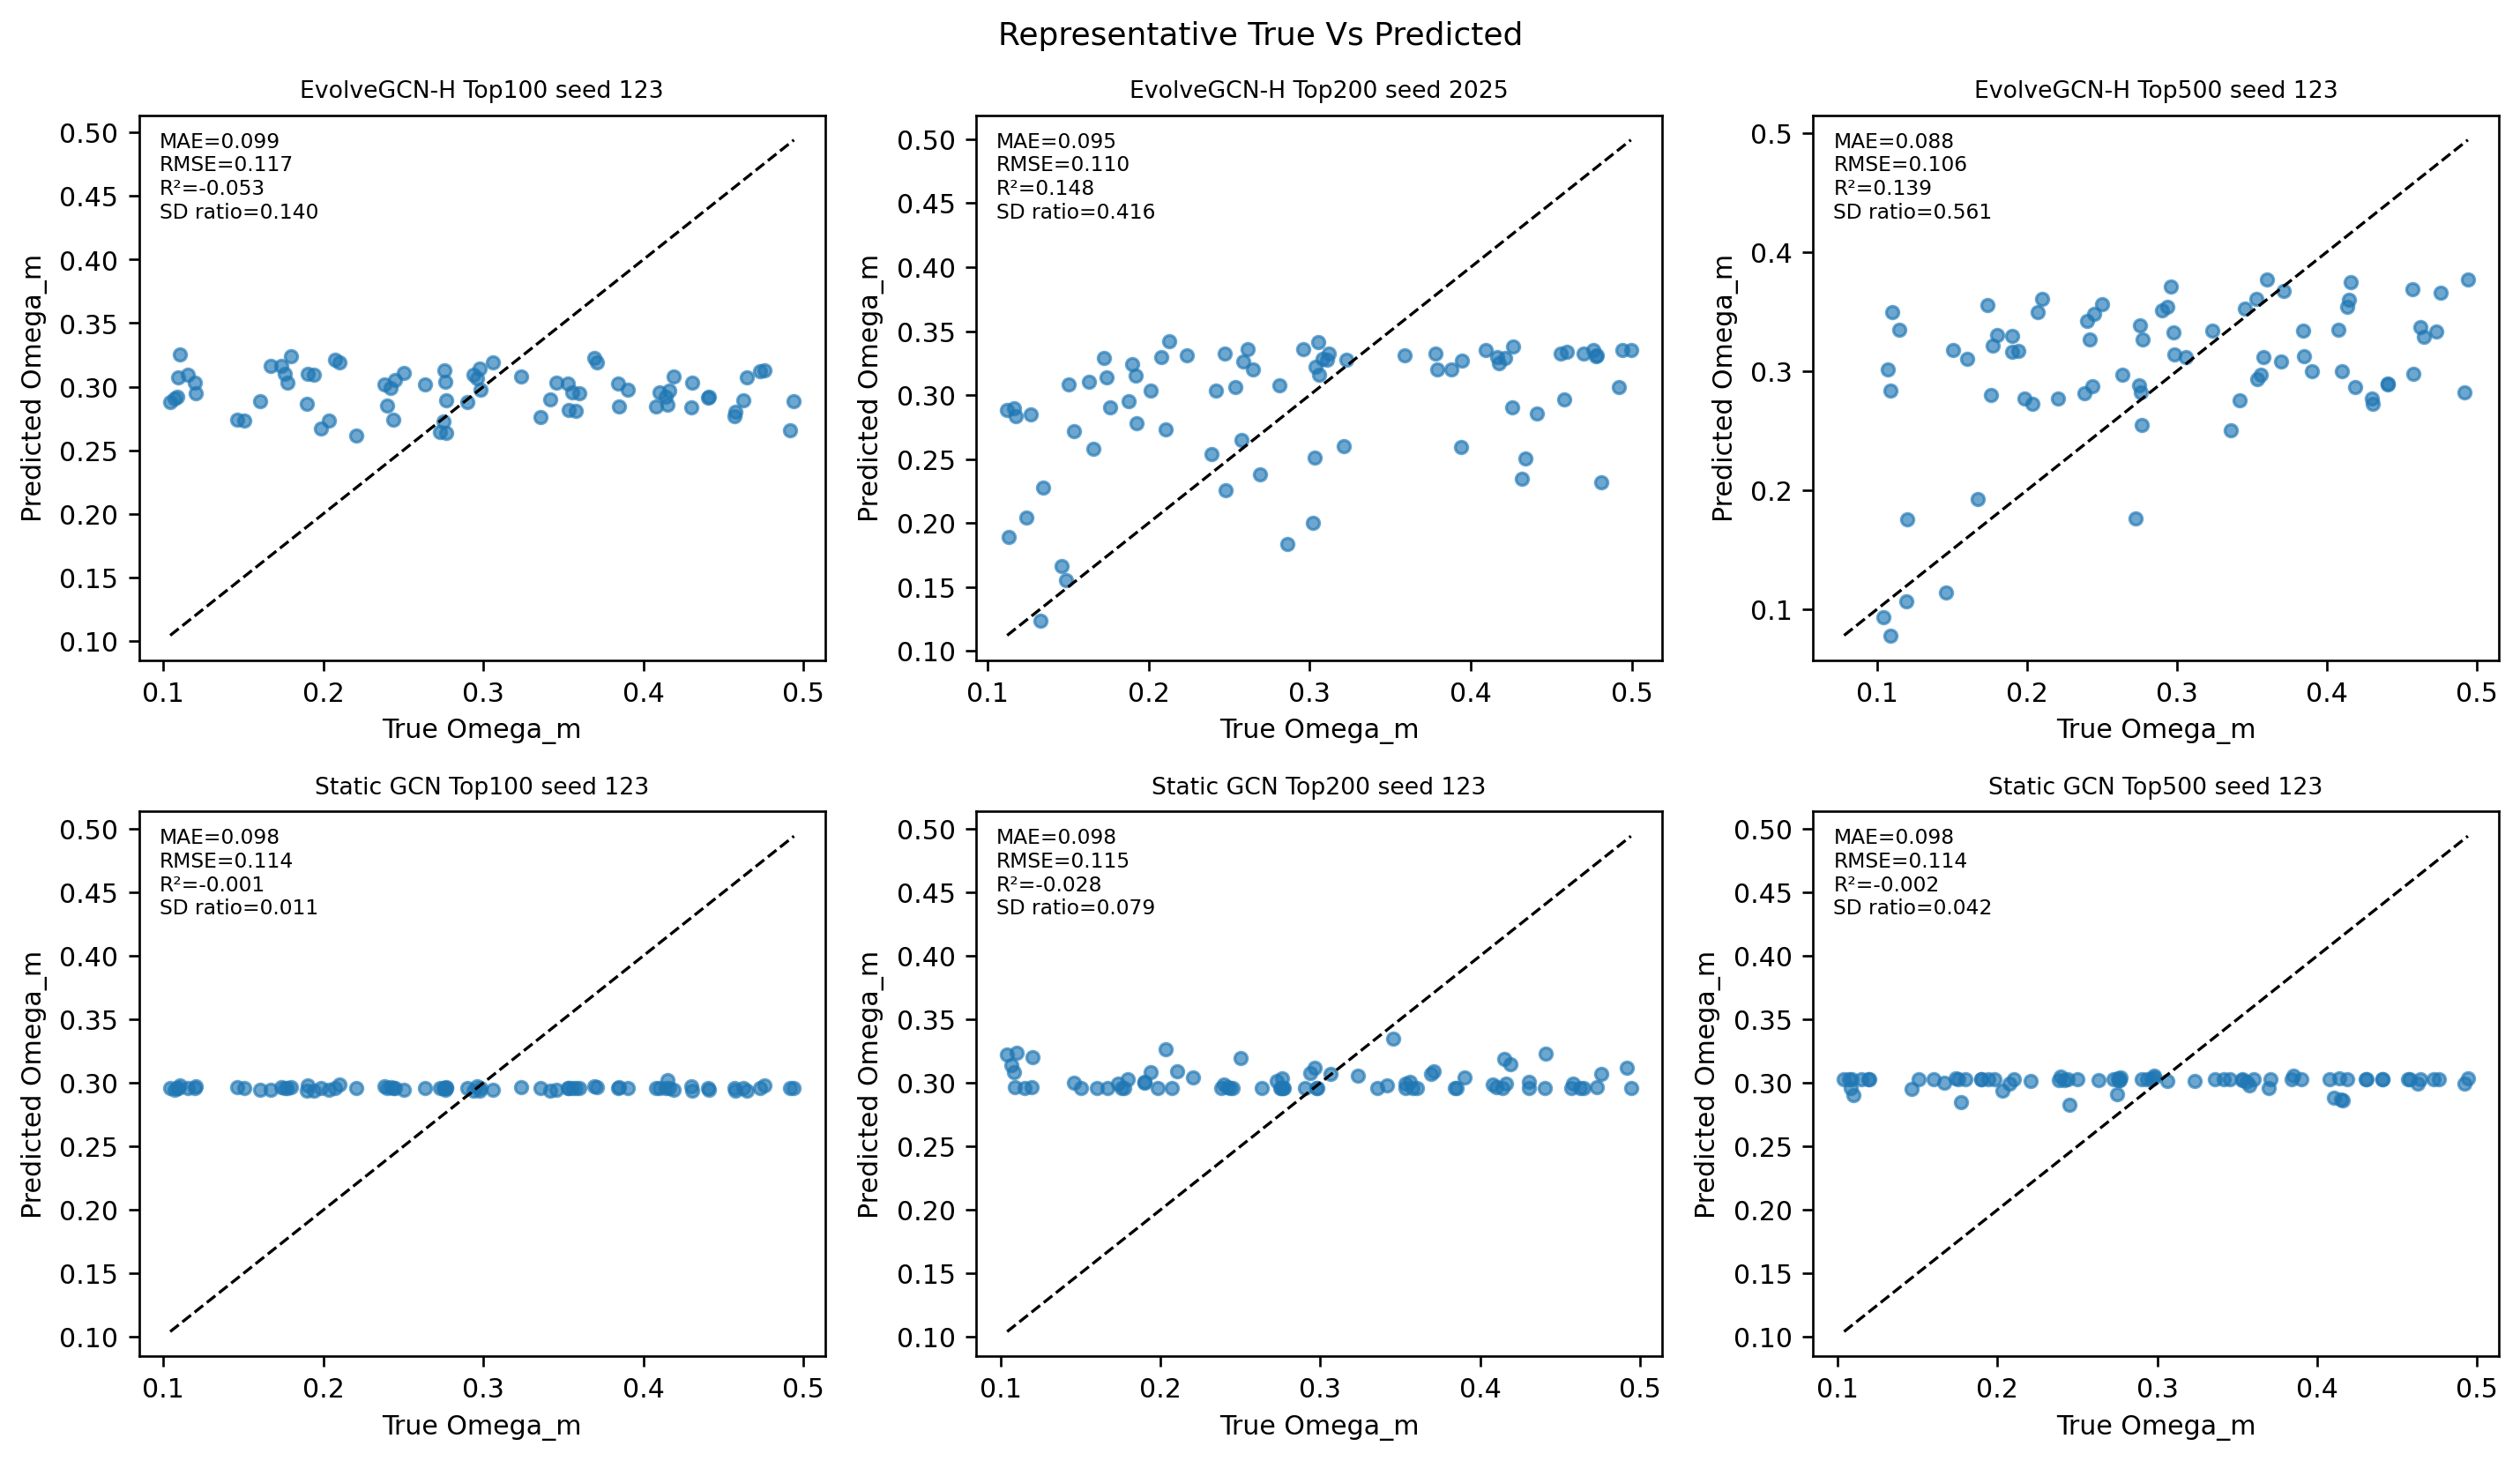

In [5]:
show_figures([
    ("topn", "representative_true_vs_predicted",
     "Median-MAE representative runs. The identity line shows where perfectly dispersed predictions would lie.")
], width=980)

<div class="callout"><b>Diagnostic principle.</b> Error, dispersion, and
repetition must be interpreted together. Representative runs use the
median-MAE seed, never the best seed.</div>

# 5 — Baseline Context

In [6]:
baseline_audit = ROOT / "reports/experiment_registry/baseline_validation_audit.md"
baseline_metrics = ROOT / "experiments/summary_features_500u_none_top500_matched_seed42/metrics.json"
if baseline_audit.is_file() and baseline_metrics.is_file():
    metrics = json.loads(baseline_metrics.read_text(encoding="utf-8"))
    baseline_rows = []
    for model, values in metrics["results"].items():
        baseline_rows.append({
            "Model": model,
            "Representation": "100 explicit summary features across five snapshots",
            "U": metrics["num_universes"],
            "Top-N": 500,
            "Seed": metrics["seed"],
            "Test MAE": values["test"]["mae"],
            "Test RMSE": values["test"]["rmse"],
            "Status": "Likely valid; raw-column semantic provenance confirmation remains",
        })
    baseline_table = pd.DataFrame(baseline_rows)
    show_table(baseline_table, precision=5, caption="Qualified summary-feature baseline context; not a finalized leaderboard")
else:
    display(HTML('<div class="caveat">A finalized authoritative baseline table was not available; this report focuses on controlled GNN ablations.</div>'))

Model,Representation,U,Top-N,Seed,Test MAE,Test RMSE,Status
Ridge,100 explicit summary features across five snapshots,500,500,42,0.02159,0.02728,Likely valid; raw-column semantic provenance confirmation remains
RandomForest,100 explicit summary features across five snapshots,500,500,42,0.01386,0.01815,Likely valid; raw-column semantic provenance confirmation remains
GradientBoosting,100 explicit summary features across five snapshots,500,500,42,0.01277,0.01670,Likely valid; raw-column semantic provenance confirmation remains


The baseline audit verifies split alignment, train-only fitting, and
feature/target separation in code. It still requests one semantic provenance
confirmation for the raw catalogue columns before promotion to a fully
validated thesis table. Accordingly, these strong tree results are evidence
that distributional summaries may carry substantial signal, but they are not
merged into an unfair GNN leaderboard.

# 6 — Experiment Roadmap

In [7]:
roadmap = pd.DataFrame([
    ("Universe-count scaling", "Independent universes", "Top100, minmax, k8, h32", 30, "Improves endpoints; non-monotonic", "Data quantity matters but is not the sole bottleneck"),
    ("Top-N scaling", "Retained halos", "U500, minmax, k8, h32", 18, "Helps Evolve; Static nearly flat", "Additional halos are model-dependently useful"),
    ("Normalization", "none / minmax / zscore", "U500 Top500 k8", 30, "None wins every matched comparison", "Absolute scales appear informative"),
    ("k × hidden dimension", "k and width", "U500 Top100 minmax", 48, "Small, inconsistent effects", "Density/width do not solve compression"),
    ("Regression head", "linear / MLP", "Evolve U750 Top1000 none", 10, "Linear modestly better", "Extra head complexity does not help"),
    ("Graph pooling", "mean / mean+max", "Evolve U750 Top1000 none", 10, "Mean wins all seeds", "Naïve extrema concatenation hurts"),
], columns=["Experiment", "Changed factor", "Fixed context", "Canonical runs", "Main result", "Scientific implication"])
roadmap["Status"] = "Complete and validated"
show_table(roadmap, caption="Finalized controlled experiment roadmap")

Experiment,Changed factor,Fixed context,Canonical runs,Main result,Scientific implication,Status
Universe-count scaling,Independent universes,"Top100, minmax, k8, h32",30,Improves endpoints; non-monotonic,Data quantity matters but is not the sole bottleneck,Complete and validated
Top-N scaling,Retained halos,"U500, minmax, k8, h32",18,Helps Evolve; Static nearly flat,Additional halos are model-dependently useful,Complete and validated
Normalization,none / minmax / zscore,U500 Top500 k8,30,None wins every matched comparison,Absolute scales appear informative,Complete and validated
k × hidden dimension,k and width,U500 Top100 minmax,48,"Small, inconsistent effects",Density/width do not solve compression,Complete and validated
Regression head,linear / MLP,Evolve U750 Top1000 none,10,Linear modestly better,Extra head complexity does not help,Complete and validated
Graph pooling,mean / mean+max,Evolve U750 Top1000 none,10,Mean wins all seeds,Naïve extrema concatenation hurts,Complete and validated


# 7 — Universe-Count Scaling

### Scientific question
Does increasing the number of independent universes improve $\Omega_m$
regression?

### Why it matters and controlled protocol
More universes expand cosmological coverage without changing Top100, minmax
preprocessing, periodic kNN k=8, h32, or the three seed identities. The two
model protocols are analyzed separately.

In [8]:
universe = read_csv("universe", "aggregated_results.csv")
show_table(
    universe,
    ["model", "universes", "seed_count", "mean_test_mae", "std_test_mae", "mean_test_rmse", "mean_test_r2"],
    {"model":"Model", "universes":"Universes", "seed_count":"Seeds", "mean_test_mae":"Mean MAE", "std_test_mae":"SD MAE", "mean_test_rmse":"Mean RMSE", "mean_test_r2":"Mean R²"},
    caption="Controlled universe-count scaling"
)

Model,Universes,Seeds,Mean MAE,SD MAE,Mean RMSE,Mean R²
EvolveGCN-H,20,3,0.1005,0.0056,0.1112,0.0045
EvolveGCN-H,50,3,0.1078,0.0176,0.1247,-0.0043
EvolveGCN-H,100,3,0.0979,0.0249,0.1184,-0.2368
EvolveGCN-H,200,3,0.1002,0.0136,0.1153,-0.0067
EvolveGCN-H,500,3,0.0970,0.0095,0.1132,-0.0324
Static GCN,20,3,0.2568,0.1895,0.2794,-8.5813
Static GCN,50,3,0.1097,0.0354,0.1281,-0.0332
Static GCN,100,3,0.0948,0.0140,0.1163,-0.2106
Static GCN,200,3,0.1012,0.0132,0.1189,-0.0786
Static GCN,500,3,0.0969,0.0095,0.1128,-0.0246


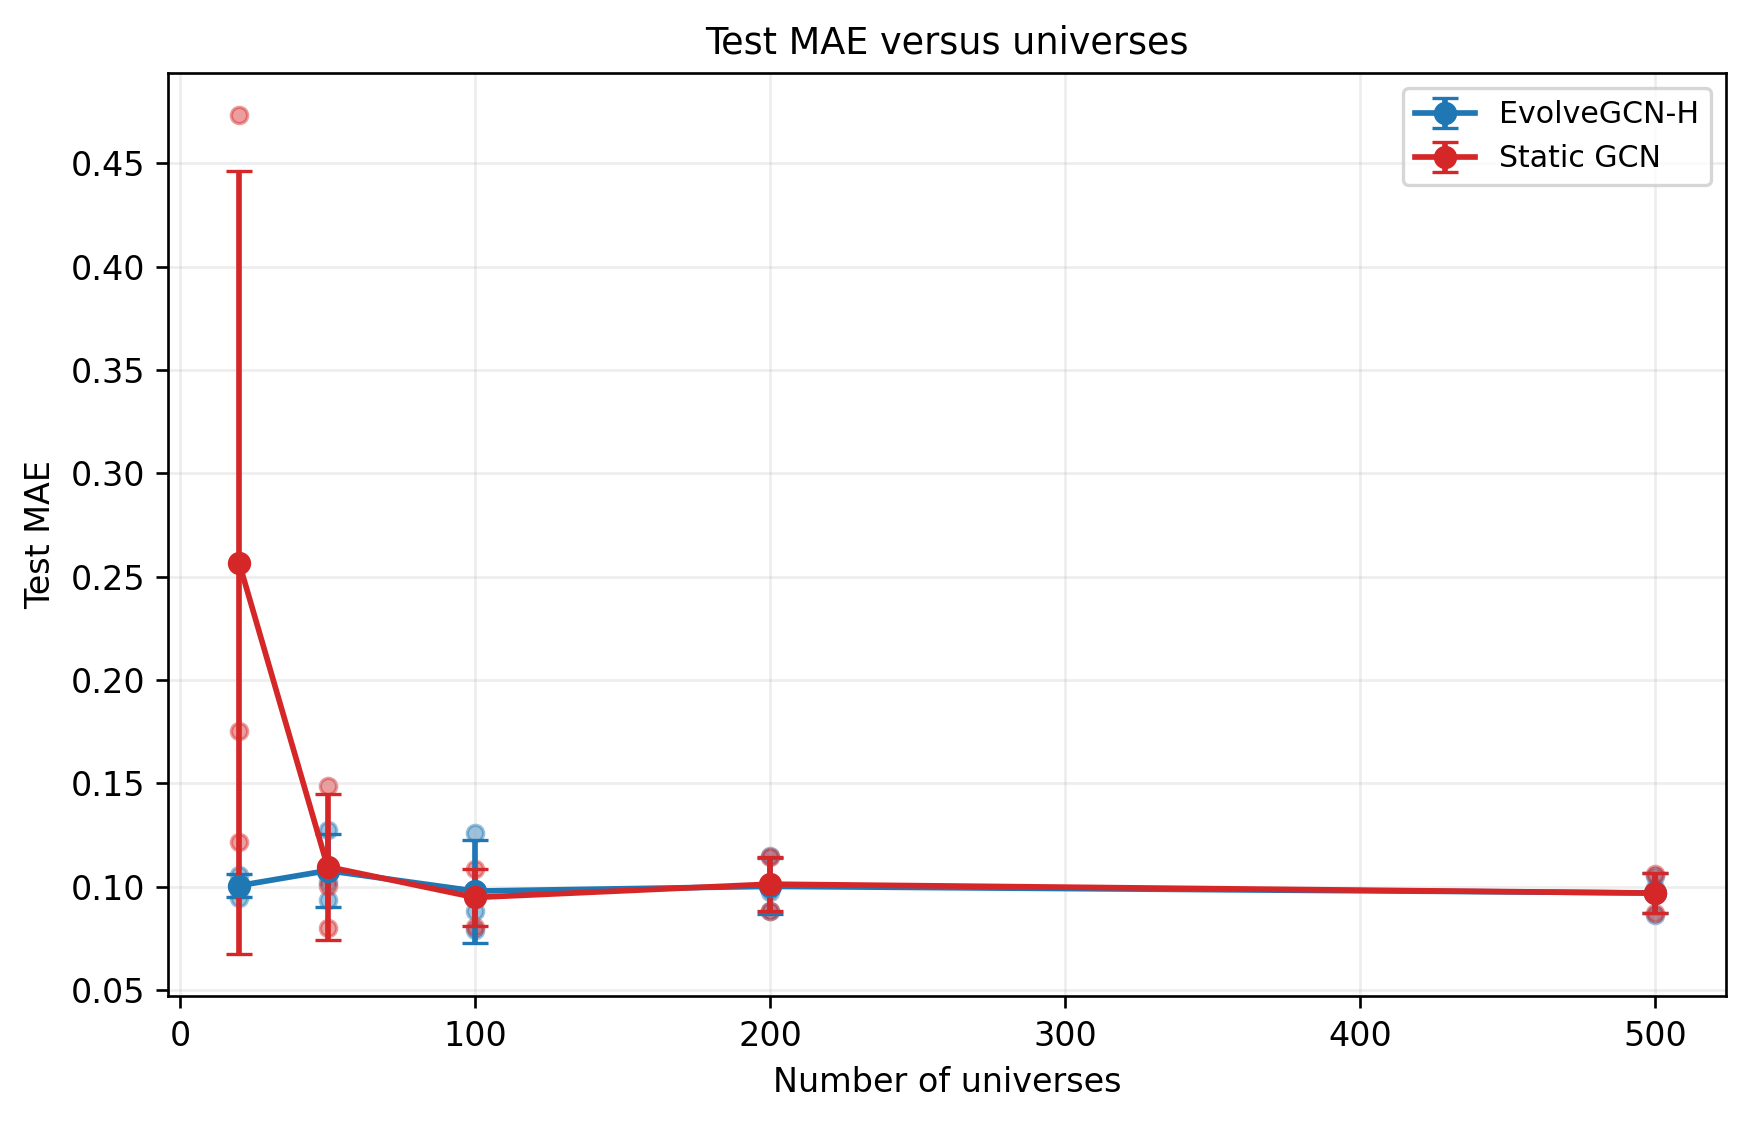

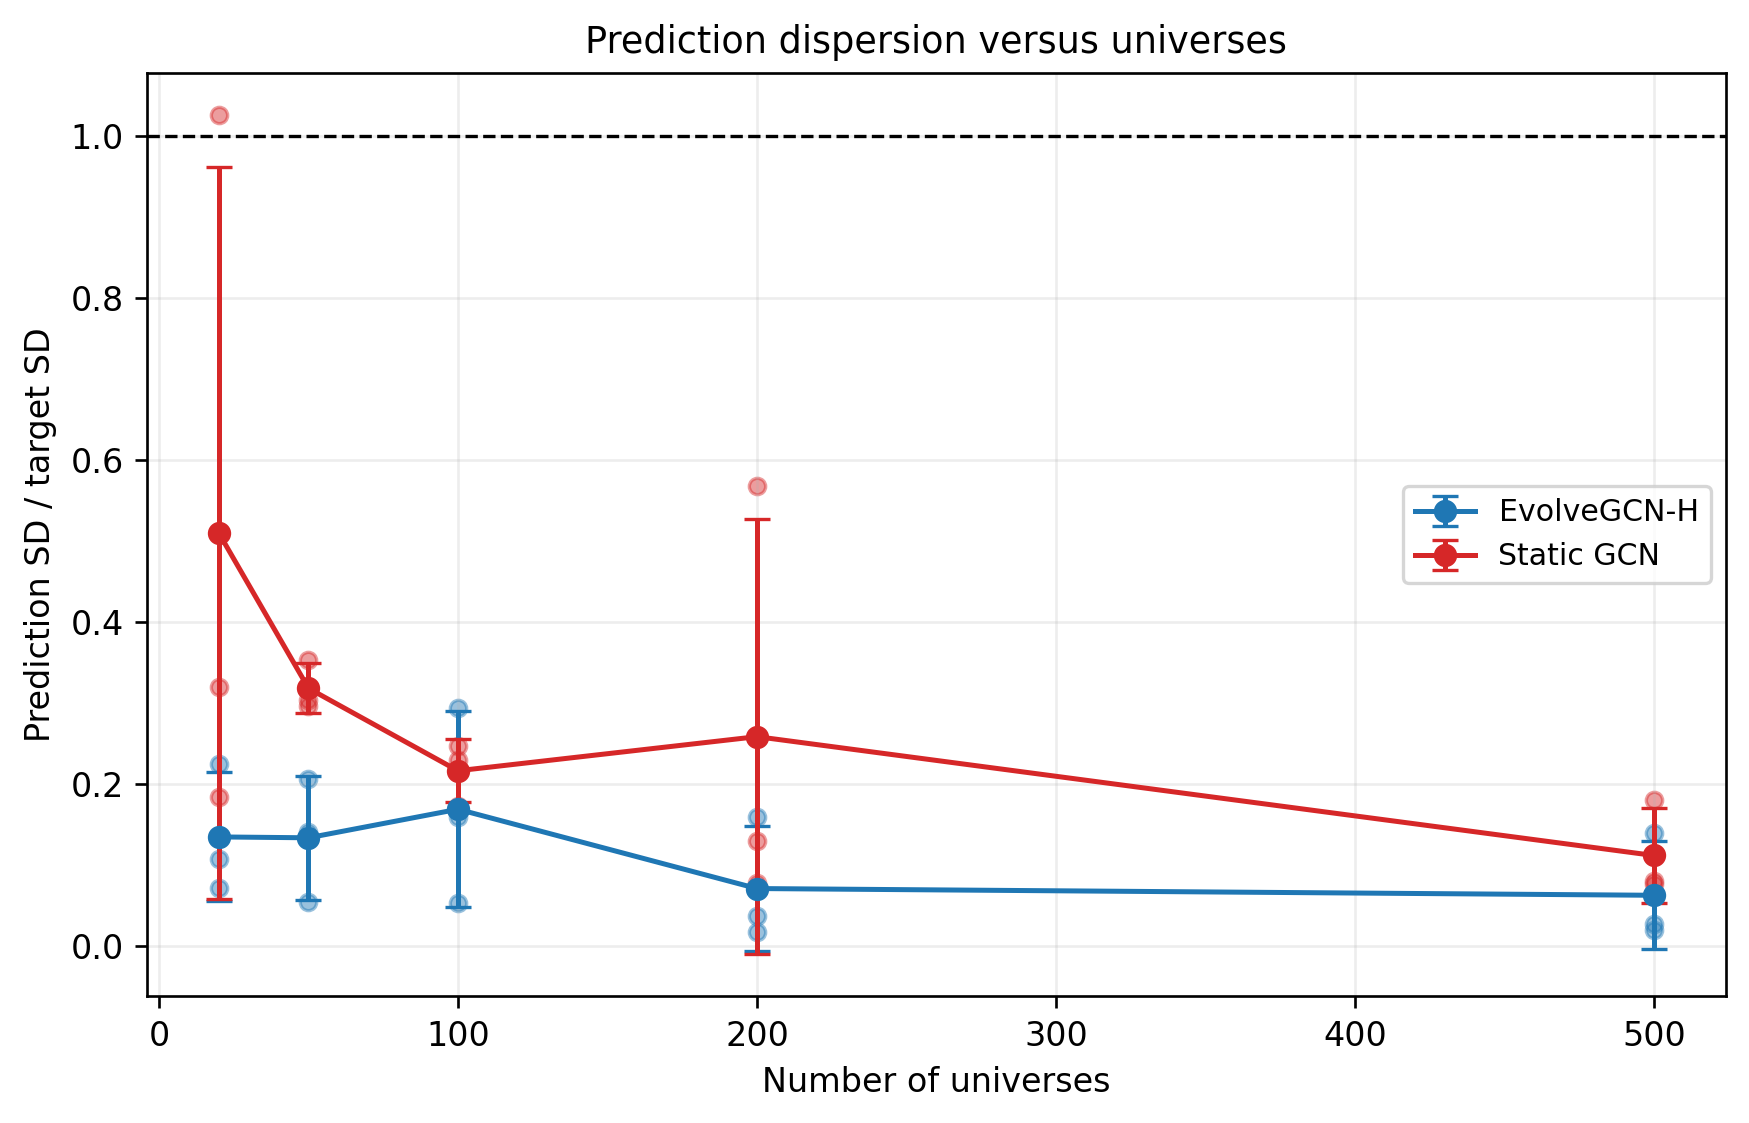

In [9]:
show_figures([
    ("universe", "test_mae_vs_universes", "Test MAE across independent-universe counts."),
    ("universe", "prediction_std_ratio_vs_universes", "Prediction-dispersion diagnostic across universe counts."),
], width=760)

### Quantitative result
Evolve mean MAE changes from **0.100515** at U20 to
**0.096962** at U500. Static changes from
**0.256783** to **0.096883**. Both endpoint
errors improve, but neither sequence is monotonic.

### Interpretation and boundary
More independent universes are useful, especially for stabilizing the Static
protocol from its small-data regime. This does not prove that temporal
processing causes cross-model differences, and adjacent populations are not
independent repetitions of a fixed dataset.

<div class="takeaway"><b>Meeting takeaway.</b> More universes help, but data
quantity alone does not remove model instability or prediction compression.</div>

<details><summary>What to say during the meeting</summary>
We first varied the number of independent cosmologies while holding the graph
protocol fixed. The endpoints improve for both models, especially Static GCN,
but the intermediate curve is not monotonic. That means additional data are
valuable, yet the remaining behavior cannot be explained by sample count
alone. Cross-model differences remain descriptive.
</details>

# 8 — Top-N Halo-Count Scaling

### Scientific question
Does retaining Top200 or Top500 rather than Top100 halos improve prediction?

### Why it matters and controlled protocol
This changes the retained halo population under U500, minmax, periodic kNN
k=8, h32, and three matched seeds. It also deterministically increases graph
cost. Because normalization follows selection, local min/max values change
with Top-N as part of the historical intervention.

In [10]:
topn = read_csv("topn", "tables/main_results_table.csv")
show_table(topn, precision=5, caption="Six-cell model-stratified Top-N result table")
computational = read_csv("topn", "tables/computational_scaling.csv")
show_table(computational, ["model","top_n","nodes_per_snapshot","directed_neighbor_selections_per_snapshot","dense_adjacency_capacity_per_snapshot","mean_test_mae"], precision=5, caption="Deterministic graph-size scaling and predictive result")

model,top_n,seed_count,mean_test_mae,sd_test_mae,median_test_mae,mean_test_rmse,sd_test_rmse,mean_test_r2,sd_test_r2,mean_prediction_sd_ratio,sd_prediction_sd_ratio,mean_exact_repeat_fraction,maximum_exact_repeat_fraction,undefined_pearson_count
EvolveGCN-H,100,3,0.09696,0.00949,0.09924,0.11324,0.00990,-0.03235,0.01953,0.06290,0.06683,0.00000,0.00000,0
EvolveGCN-H,200,3,0.09217,0.00833,0.09457,0.10970,0.00859,0.02571,0.11433,0.39400,0.07576,0.00000,0.00000,0
EvolveGCN-H,500,3,0.08617,0.00426,0.08809,0.10285,0.00354,0.14130,0.09399,0.49410,0.11405,0.00000,0.00000,0
Static GCN,100,3,0.09626,0.00834,0.09759,0.11213,0.00854,-0.01342,0.01485,0.04330,0.02762,0.44889,0.92000,0
Static GCN,200,3,0.09698,0.00984,0.09828,0.11292,0.01005,-0.02629,0.01504,0.07075,0.06719,0.46667,0.98667,1
Static GCN,500,3,0.09604,0.00892,0.09798,0.11175,0.00934,-0.00579,0.00532,0.06351,0.07628,0.46222,0.98667,1


model,top_n,nodes_per_snapshot,directed_neighbor_selections_per_snapshot,dense_adjacency_capacity_per_snapshot,mean_test_mae
EvolveGCN-H,100,100,800,10000,0.09696
EvolveGCN-H,200,200,1600,40000,0.09217
EvolveGCN-H,500,500,4000,250000,0.08617
Static GCN,100,100,800,10000,0.09626
Static GCN,200,200,1600,40000,0.09698
Static GCN,500,500,4000,250000,0.09604


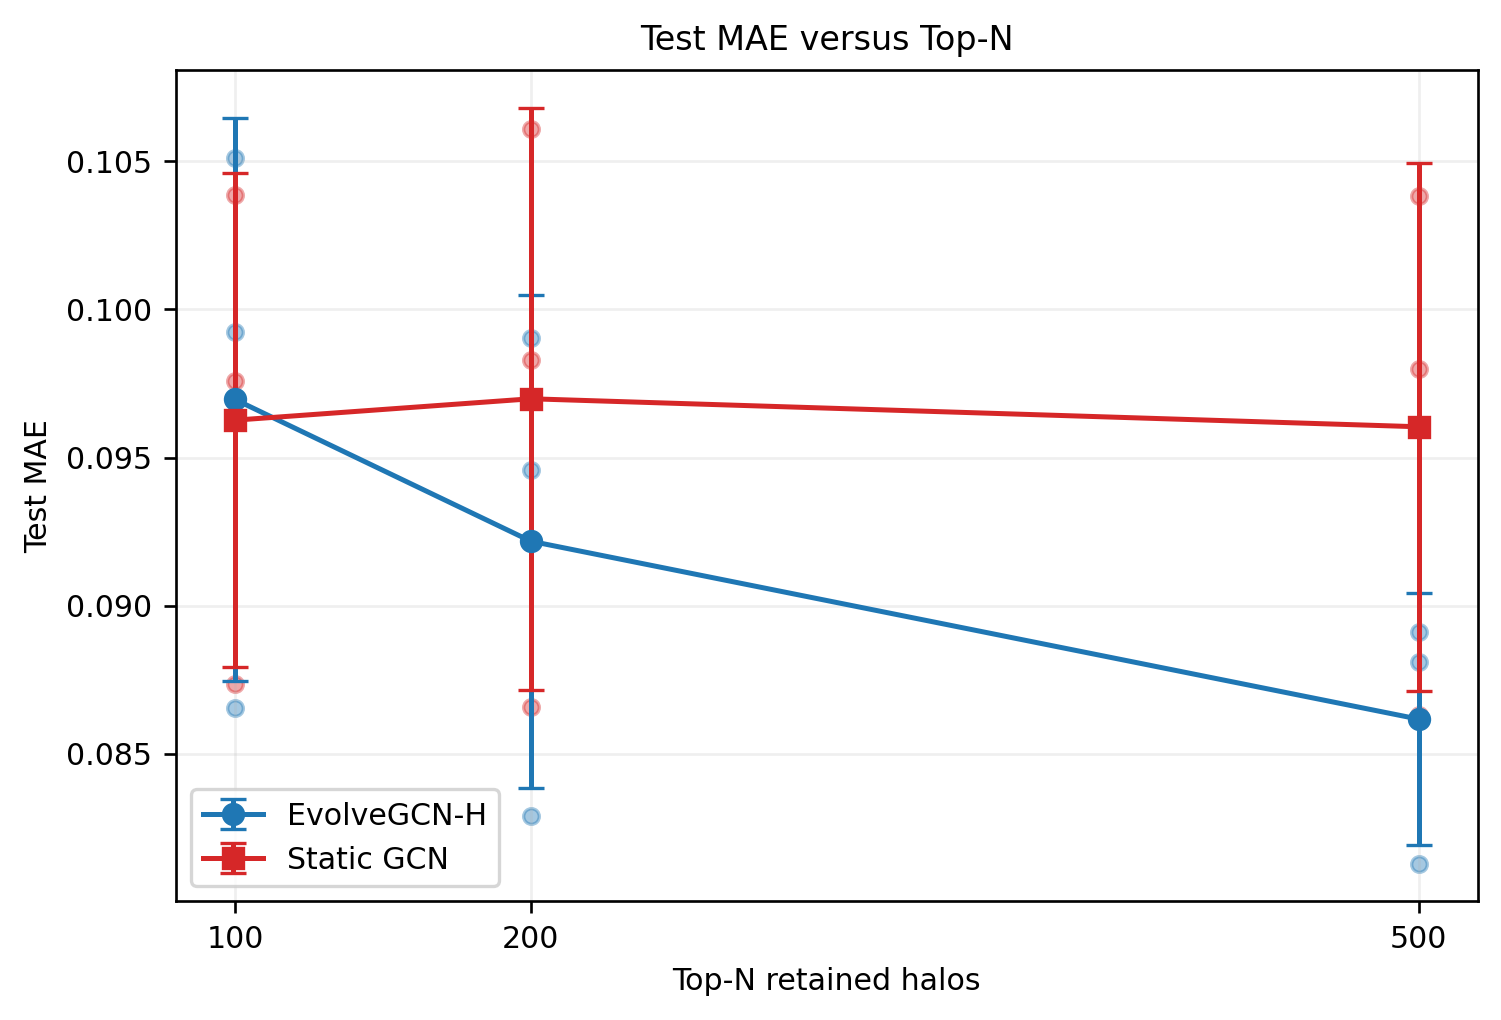

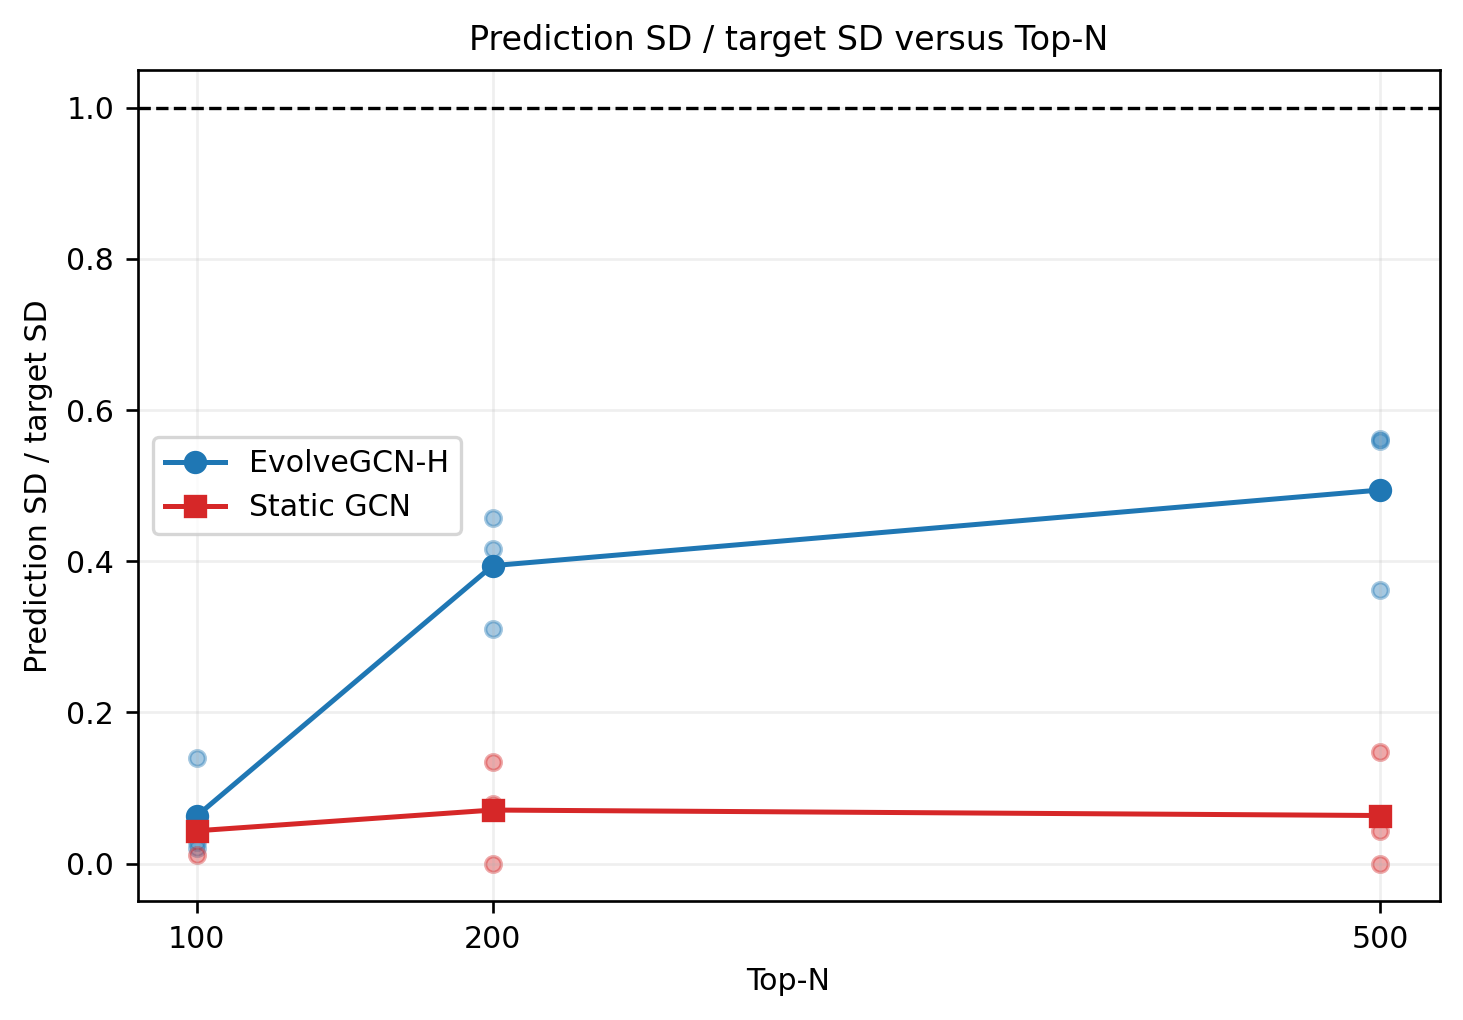

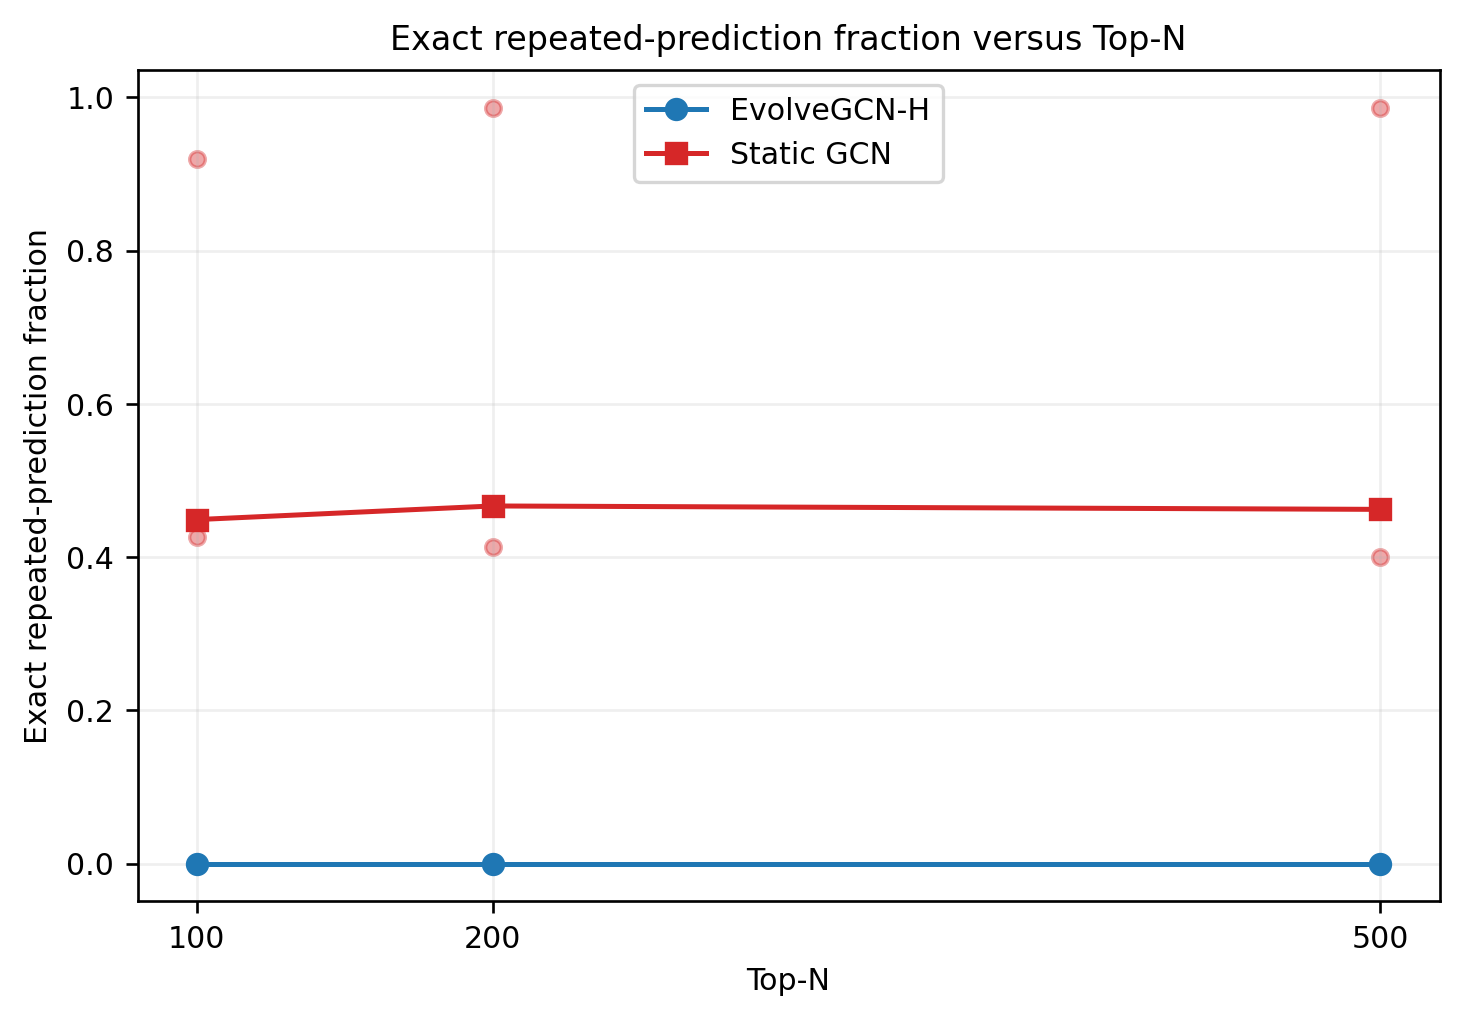

In [11]:
show_figures([
    ("topn", "test_mae_vs_topn", "Matched-seed MAE versus retained halo count."),
    ("topn", "prediction_std_ratio_vs_topn", "Prediction dispersion versus retained halo count."),
    ("topn", "repeated_prediction_fraction_vs_topn", "Exact prediction repetition versus retained halo count."),
], width=760)

### Quantitative result
Evolve MAE improves **0.096962 → 0.092174 →
0.086166**, with the larger Top-N winning every matched
comparison. Its mean SD ratio improves **0.063 →
0.394 → 0.494**.
Static MAE remains near 0.096 and exact-repeat fractions remain approximately
0.45–0.46.

### Interpretation and boundary
Additional halos provide useful information to EvolveGCN-H, but Static GCN
does not use the larger population effectively. Compression is reduced, not
eliminated. Top500 uses 5× the nodes and 25× dense adjacency capacity of
Top100; wall time and memory were not recorded. Three seeds limit inference.

<div class="takeaway"><b>Meeting takeaway.</b> More halos help EvolveGCN-H
consistently, but node count alone does not solve prediction collapse.</div>

<details><summary>What to say during the meeting</summary>
This is the clearest positive scaling result for EvolveGCN-H. Every matched
seed improves from Top100 to Top200 and again to Top500, and dispersion moves
closer to the target dispersion. Static GCN stays almost flat and continues to
repeat predictions. The gain is therefore model-dependent and comes with
substantial graph-size growth.
</details>

# 9 — Normalization Ablation

### Scientific question
Does per-universe, per-snapshot feature normalization improve regression?

### Why it matters and controlled protocol
At U500 Top500 k8, five matched seeds compare no scaling after log-mass,
sample-local minmax, and sample-local zscore. Targets are never normalized;
raw XYZ remains separate for graph topology.

In [12]:
normalization = read_csv("normalization", "aggregated_results.csv")
show_table(normalization, ["model","normalization","seed_count","mean_test_mae","sd_test_mae","mean_test_rmse","mean_test_r2","mean_prediction_sd_ratio","mean_repeated_prediction_fraction"], precision=5, caption="Controlled normalization ablation")

model,normalization,seed_count,mean_test_mae,sd_test_mae,mean_test_rmse,mean_test_r2,mean_prediction_sd_ratio,mean_repeated_prediction_fraction
EvolveGCN-H,none,5,0.06580,0.00492,0.08003,0.47234,0.69069,0.03200
EvolveGCN-H,minmax,5,0.08500,0.00443,0.10090,0.16521,0.48325,0.00000
EvolveGCN-H,zscore,5,0.09455,0.00651,0.11039,0.00773,0.25365,0.00000
Static GCN,none,5,0.04530,0.00373,0.05661,0.73466,0.84581,0.00000
Static GCN,minmax,5,0.09599,0.00642,0.11222,-0.02447,0.11066,0.42667
Static GCN,zscore,5,0.09934,0.00561,0.11636,-0.10377,0.26214,0.05600


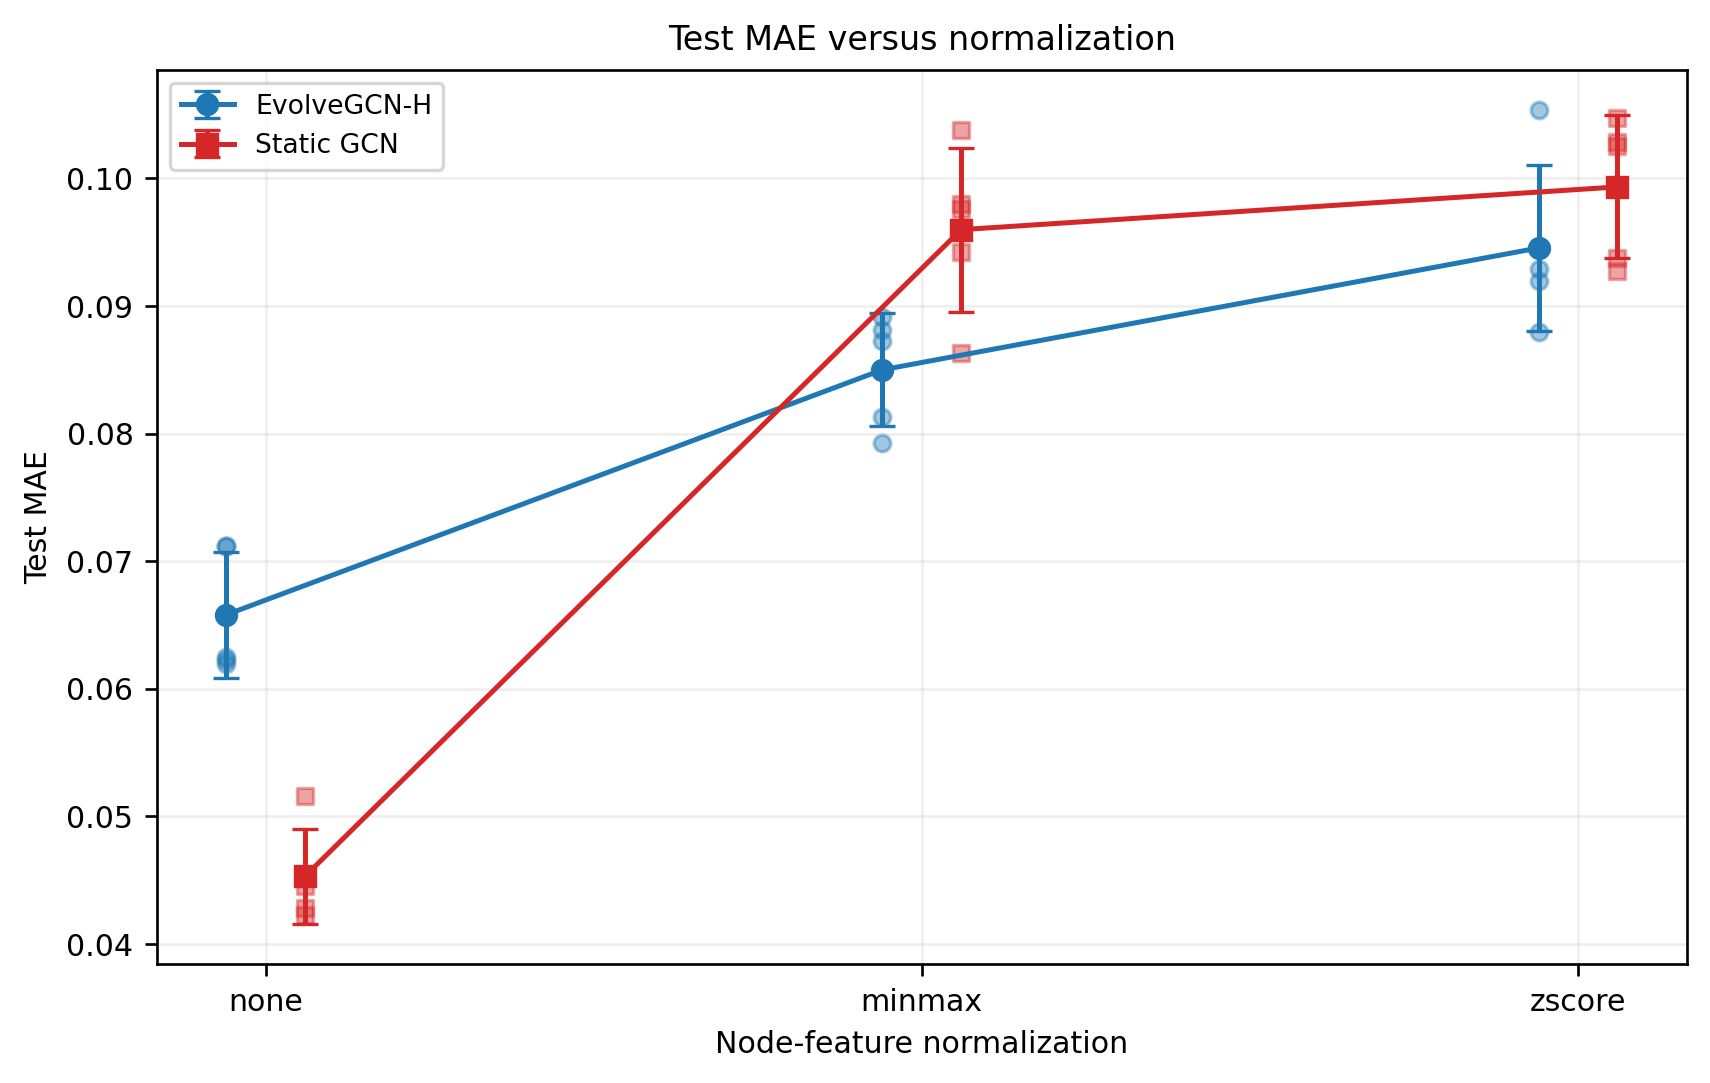

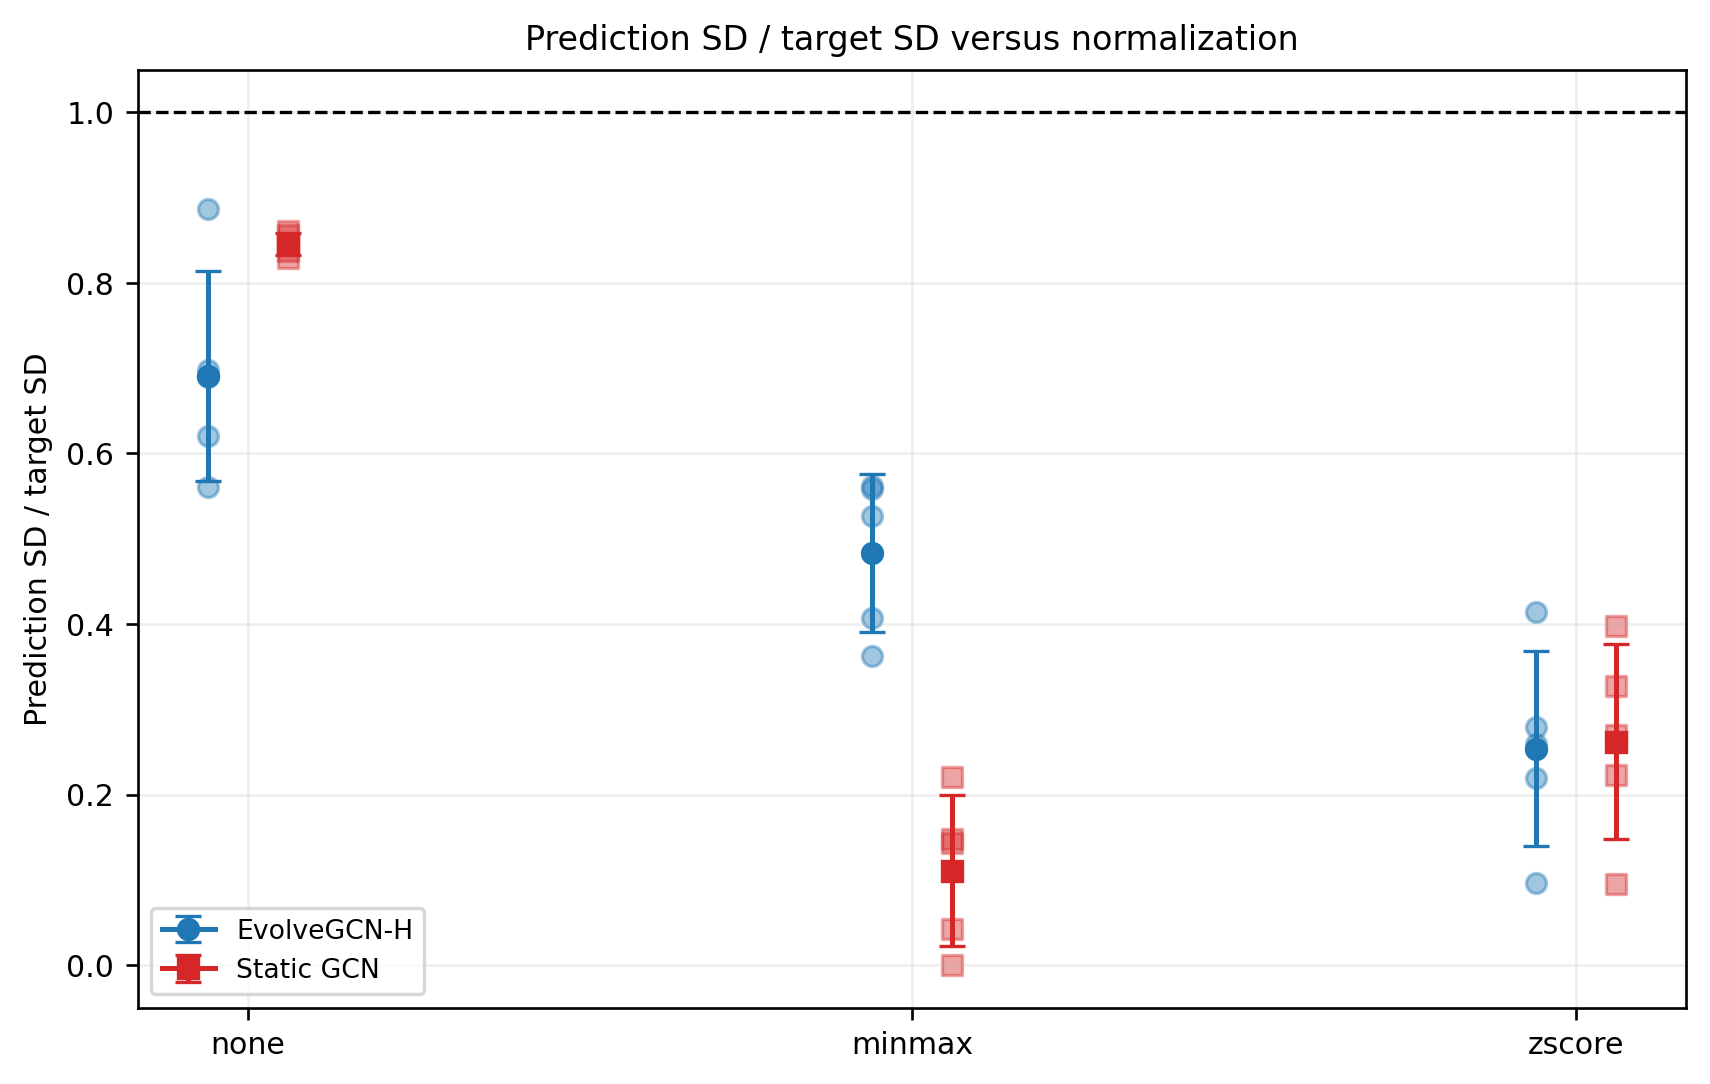

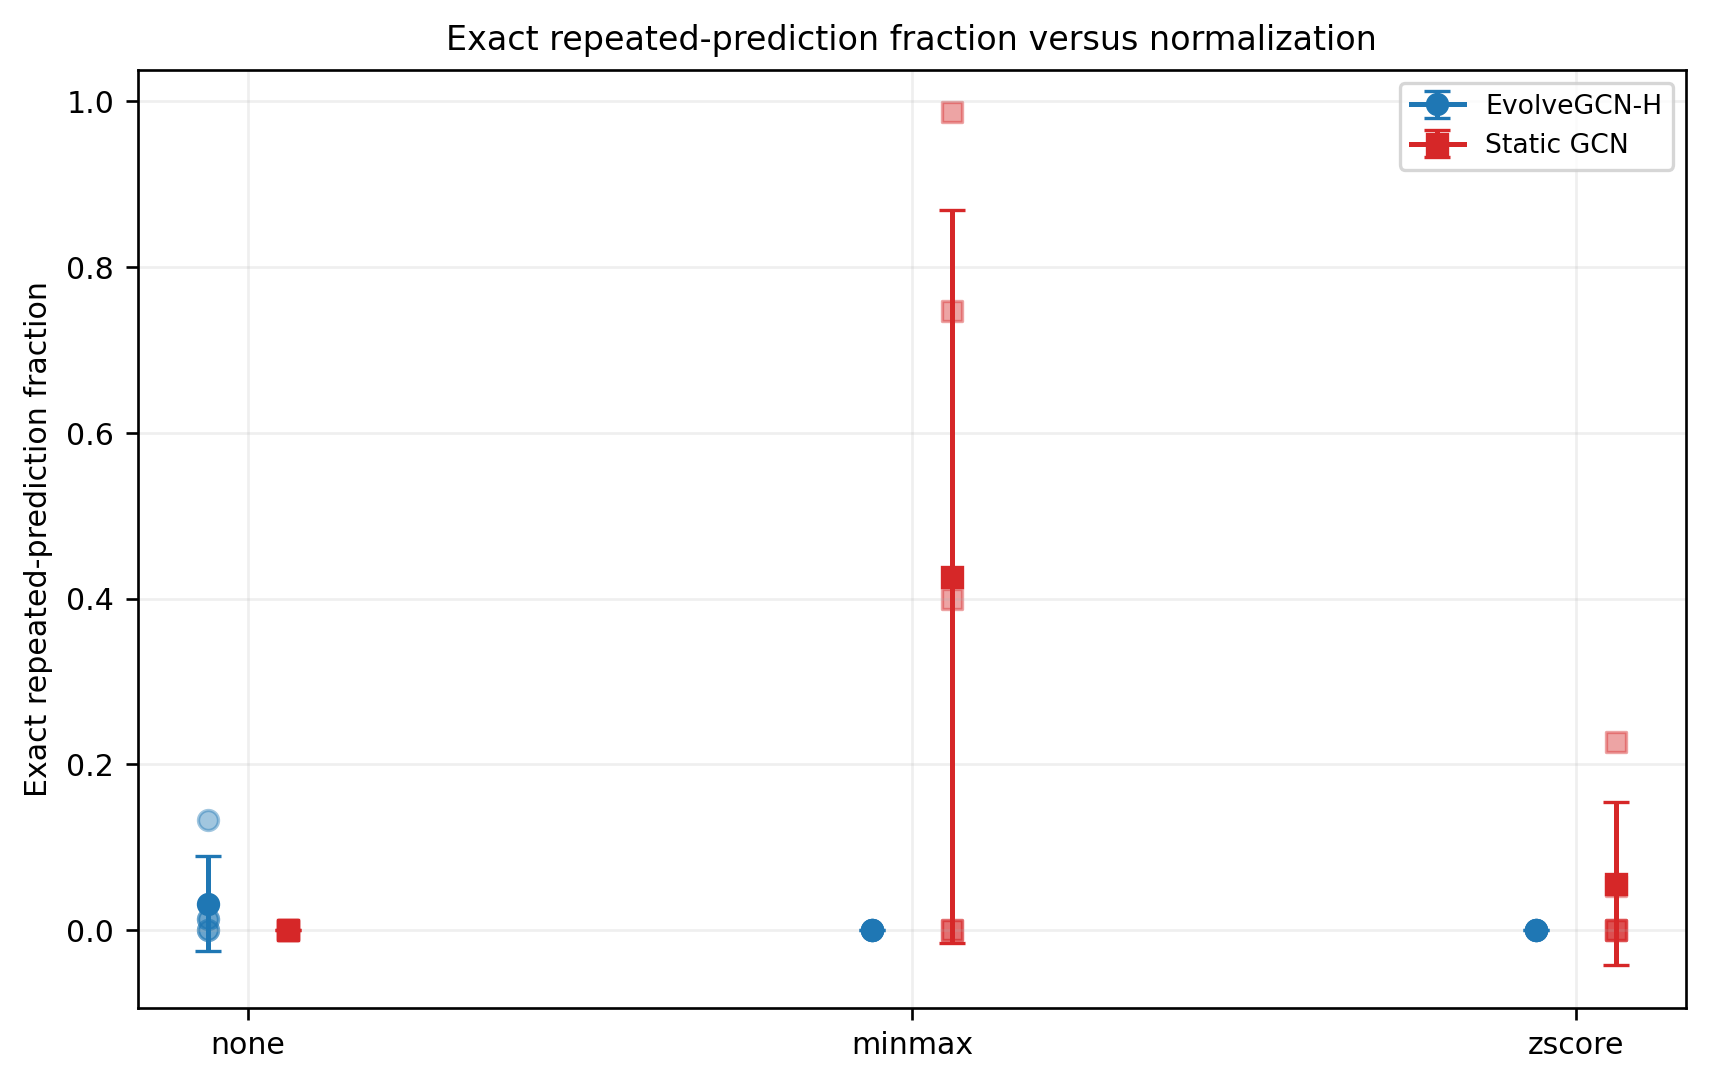

In [13]:
show_figures([
    ("normalization", "test_mae_vs_normalization", "Five-seed test MAE by feature-scaling method."),
    ("normalization", "prediction_std_ratio_vs_normalization", "Prediction dispersion by feature-scaling method."),
    ("normalization", "repeated_prediction_fraction_vs_normalization", "Exact prediction repetition by feature-scaling method."),
], width=760)

### Quantitative result
Evolve mean MAE is **0.065798** without scaling,
**0.085000** with minmax, and
**0.094548** with zscore. Static is
**0.045304**, **0.095986**, and
**0.099335**. None wins every matched
none-versus-normalized comparison.

### Interpretation and boundary
Sample-local transformations remove absolute between-universe scales that may
encode cosmology. This finding applies to the tested per-universe,
per-snapshot implementation; it does not establish that all normalization is
harmful.

<div class="takeaway"><b>Meeting takeaway.</b> Preserving absolute feature
scales is the strongest preprocessing result in the completed experiments.</div>

<details><summary>What to say during the meeting</summary>
Normalization was expected to stabilize optimization, but the controlled
result goes the other way. The raw-scale variants win for every matched seed
in both models. A plausible interpretation is that sample-local scaling
removes absolute mass or phase-space information between universes. This is an
implementation-specific conclusion, not a rejection of normalization in
general.
</details>

# 10 — kNN Connectivity × Hidden-Dimension Factorial

### Scientific question
Can denser graph connectivity or a wider hidden representation explain the
remaining weakness?

### Why it matters and controlled protocol
The 48-run factorial crosses two models, k={4,6,8,12}, h={32,64}, and three
matched seeds at U500 Top100 minmax. This separates connectivity, width, and
their descriptive interaction.

In [14]:
factorial = read_csv("factorial", "aggregated_results.csv")
compact = factorial[["model","hidden_dim","k","seed_count","mean_test_mae","std_test_mae","mean_test_r2","mean_prediction_std_ratio"]]
show_table(compact, precision=5, caption="Sixteen aggregate factorial cells; 48 seed-level runs are retained in the package")

model,hidden_dim,k,seed_count,mean_test_mae,std_test_mae,mean_test_r2,mean_prediction_std_ratio
EvolveGCN-H,32,4,3,0.09671,0.00995,-0.02496,0.04156
EvolveGCN-H,32,6,3,0.09642,0.00948,-0.02194,0.03963
EvolveGCN-H,32,8,3,0.09696,0.00949,-0.03235,0.06290
EvolveGCN-H,32,12,3,0.09618,0.00902,-0.02298,0.04514
EvolveGCN-H,64,4,3,0.09777,0.01178,-0.04877,0.11370
EvolveGCN-H,64,6,3,0.09690,0.00989,-0.03806,0.08901
EvolveGCN-H,64,8,3,0.09656,0.00995,-0.02900,0.09149
EvolveGCN-H,64,12,3,0.09745,0.01161,-0.03884,0.11409
Static GCN,32,4,3,0.09585,0.00877,-0.00445,0.02845
Static GCN,32,6,3,0.09510,0.00823,0.00157,0.09417


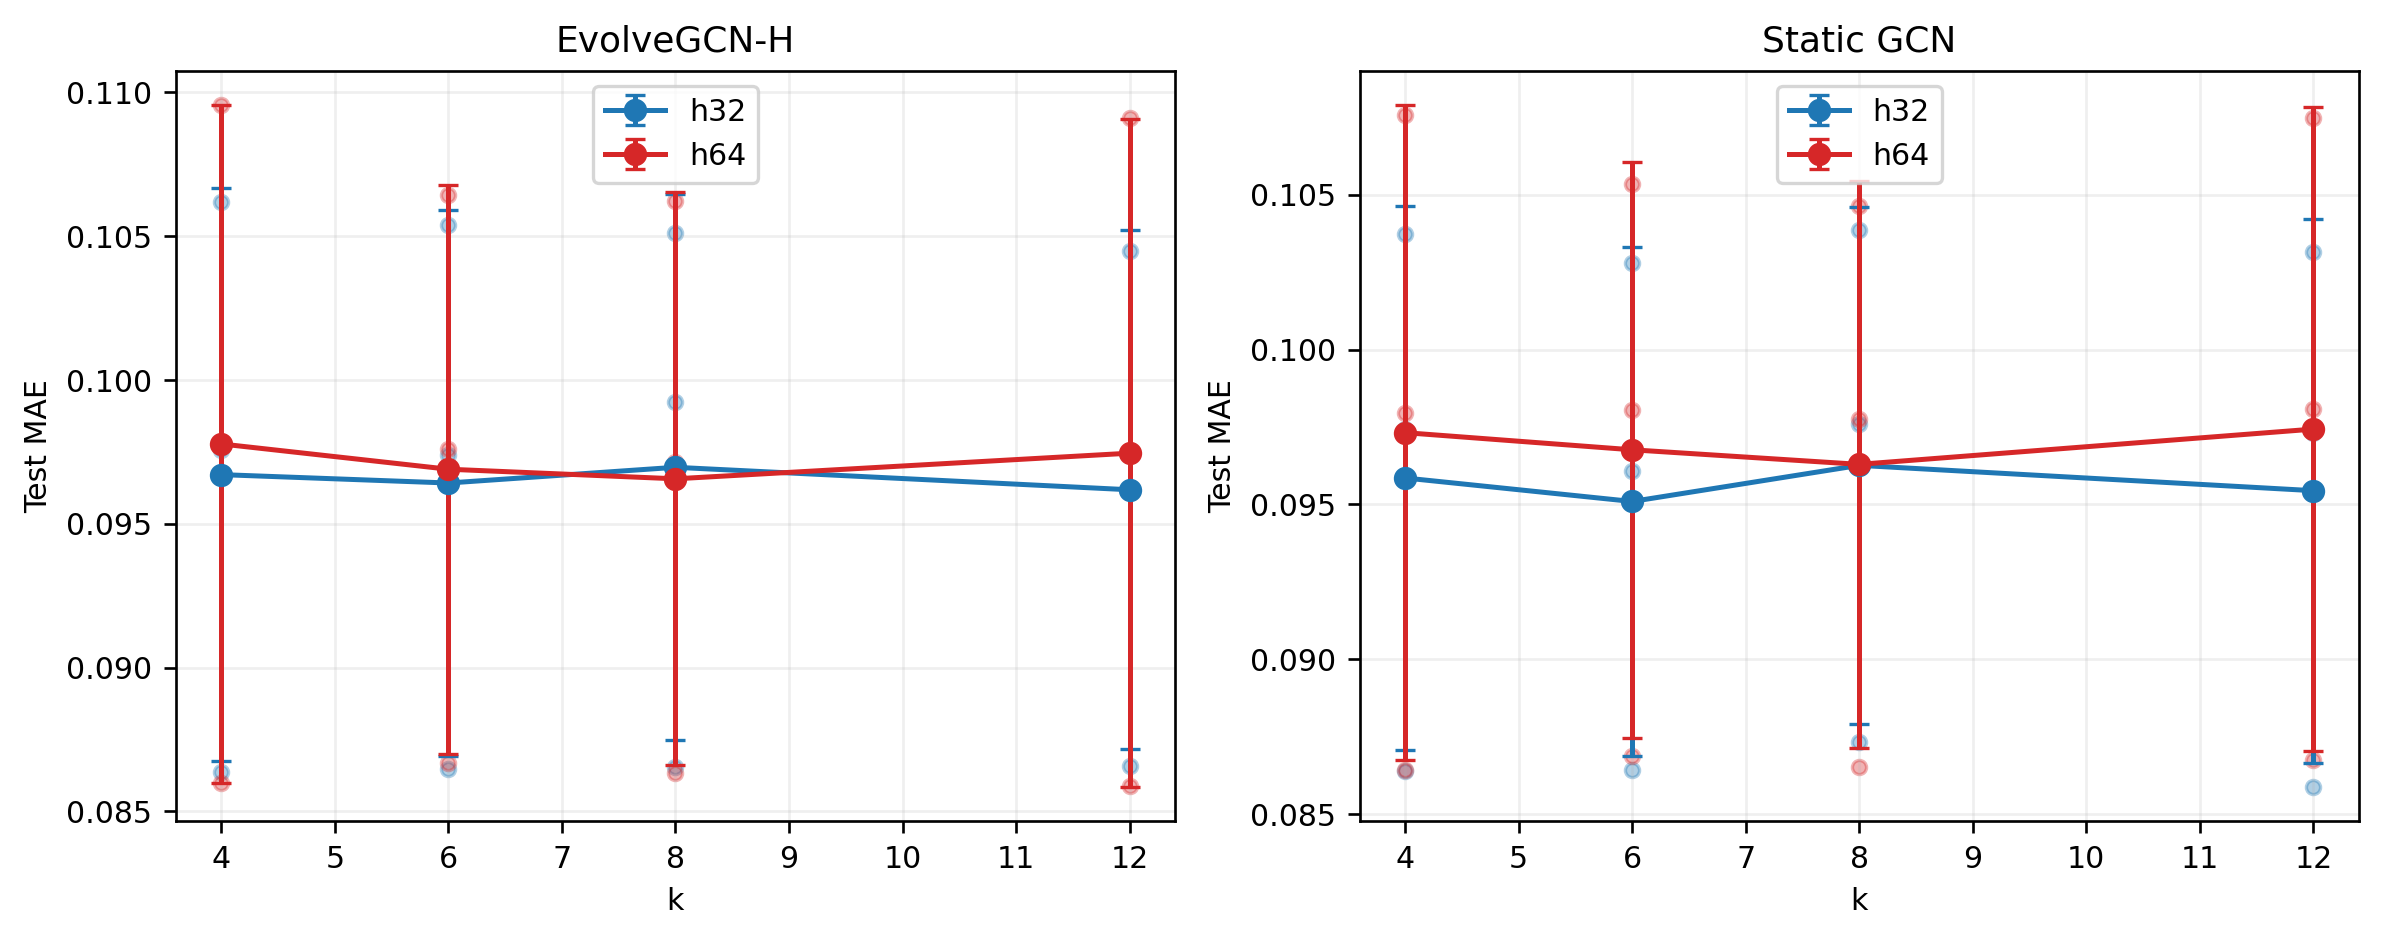

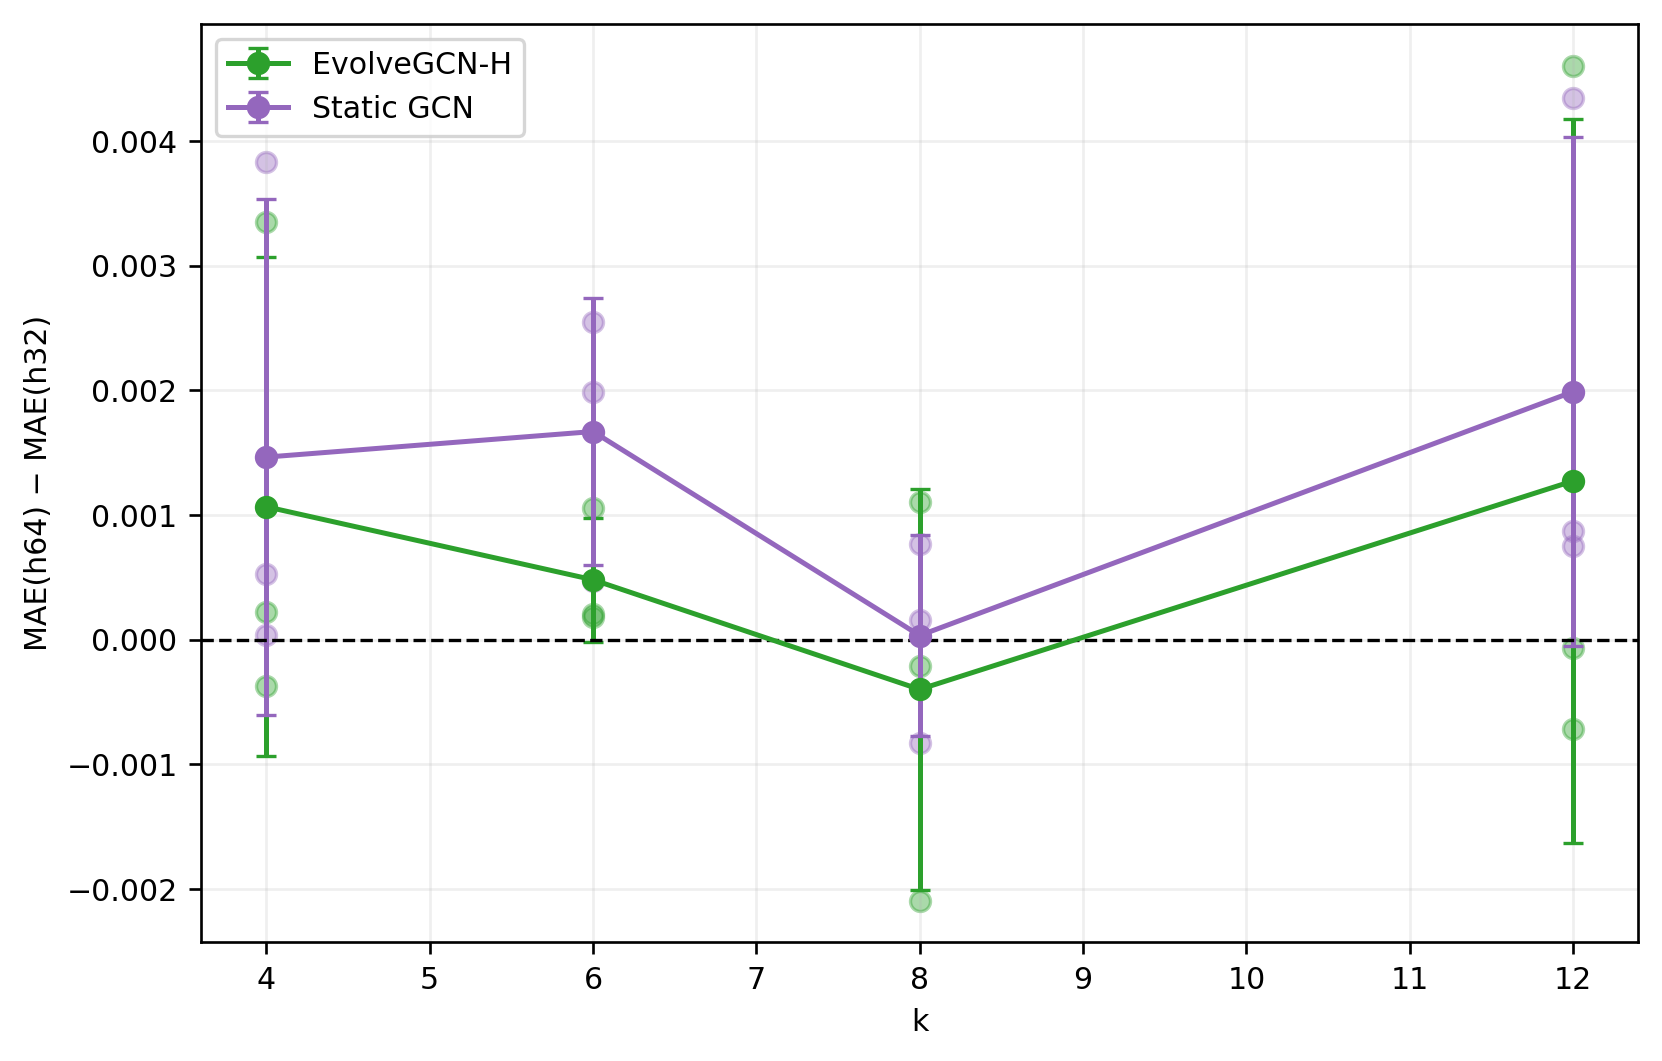

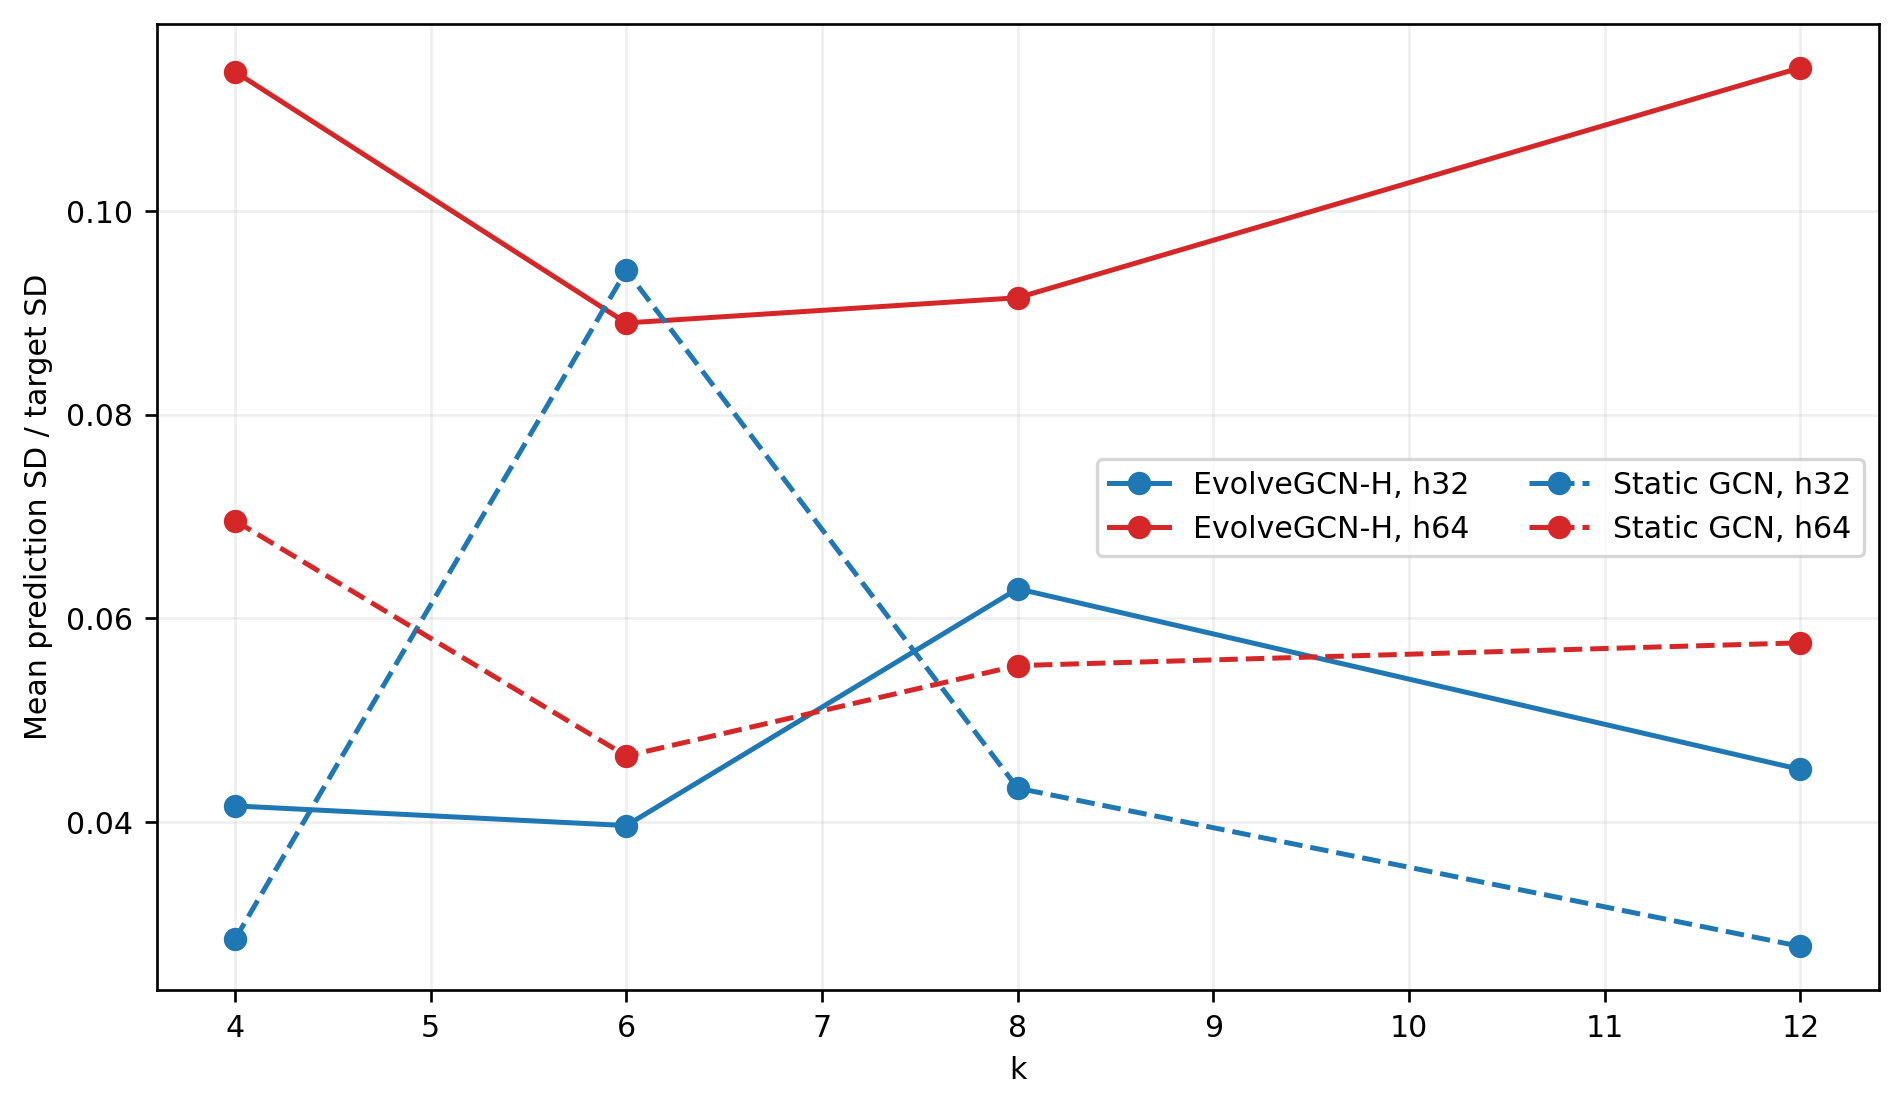

In [15]:
show_figures([
    ("factorial", "test_mae_vs_k_by_hidden_dim", "MAE versus k, separated by model and hidden width."),
    ("factorial", "paired_width_mae_difference_vs_k", "Matched h64-minus-h32 MAE differences."),
    ("factorial", "prediction_std_ratio_vs_k_and_width", "Prediction dispersion across k and width."),
], width=760)

### Quantitative result
k effects are generally small relative to between-seed variability. No k
improves every model and width. Evolve h64 beats h32 in 5/12 matched rows;
Static h64 does so in 1/12. Width effects change sign with k, providing
descriptive—not inferential—interaction evidence.

### Interpretation and boundary
Graph density and width alone do not explain or resolve compression. The
result does not prove that connectivity is irrelevant, only that these four k
values and two widths lack a consistent benefit under the tested protocol.

<div class="takeaway"><b>Meeting takeaway.</b> Basic capacity and connectivity
tuning does not address the central representation/readout bottleneck.</div>

<details><summary>What to say during the meeting</summary>
This factorial prevents us from blaming a single default k or hidden width.
The best k changes by model and width, and h64 is not reliably better. Several
collapsed rows remain even at denser connectivity. These negative results
narrow the next step away from routine hyperparameter expansion.
</details>

# 11 — Regression-Head Ablation

### Scientific question
Does a nonlinear MLP head map the pooled EvolveGCN-H representation better
than a direct linear head?

### Why it matters and controlled protocol
Five exact U750 Top1000 no-normalization seed pairs hold the encoder, graph
mean pooling, temporal mean pooling, optimization, and splits fixed.

In [16]:
head = read_csv("head", "aggregated_results.csv")
show_table(head, ["head_type","seed_count","head_parameter_count","mean_test_mae","sd_test_mae","mean_test_rmse","mean_test_r2","mean_prediction_sd_ratio","mean_repeated_prediction_fraction"], precision=5, caption="Controlled regression-head result")

head_type,seed_count,head_parameter_count,mean_test_mae,sd_test_mae,mean_test_rmse,mean_test_r2,mean_prediction_sd_ratio,mean_repeated_prediction_fraction
linear,5,33,0.05584,0.00875,0.07114,0.62770,0.86246,0.00000
mlp,5,1089,0.06140,0.00514,0.07682,0.57118,0.77929,0.06169


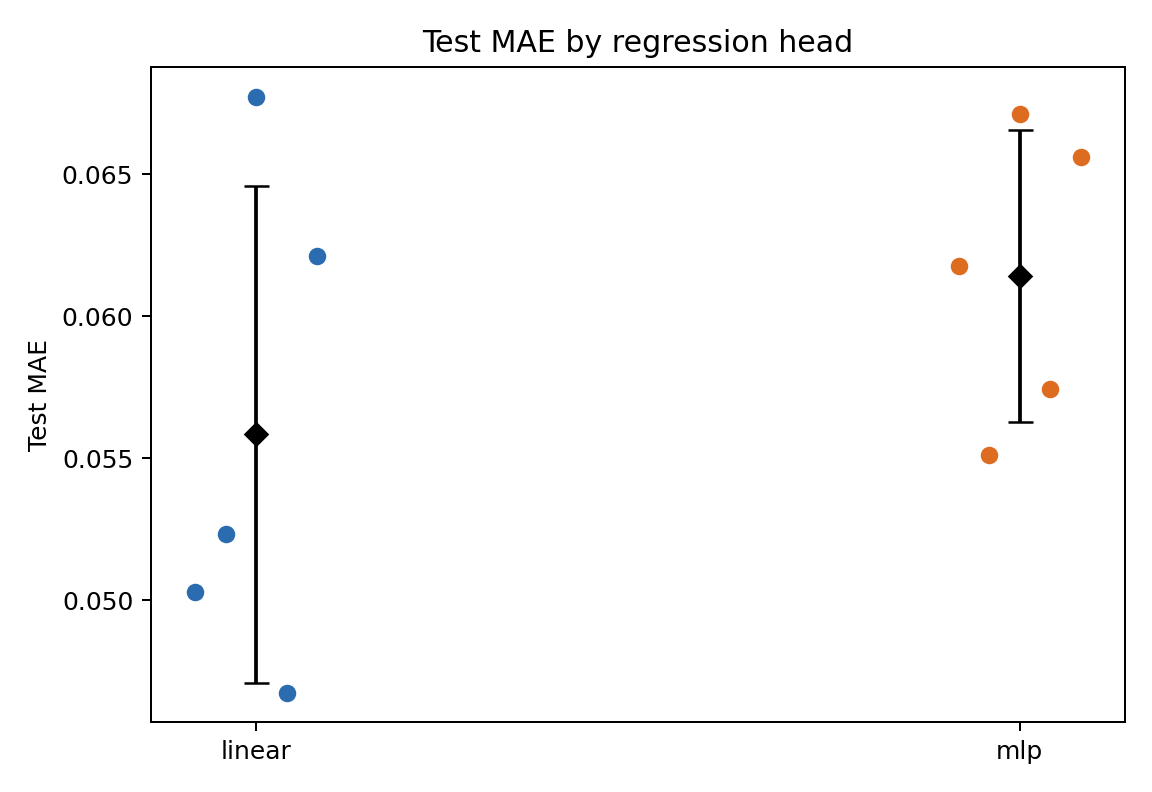

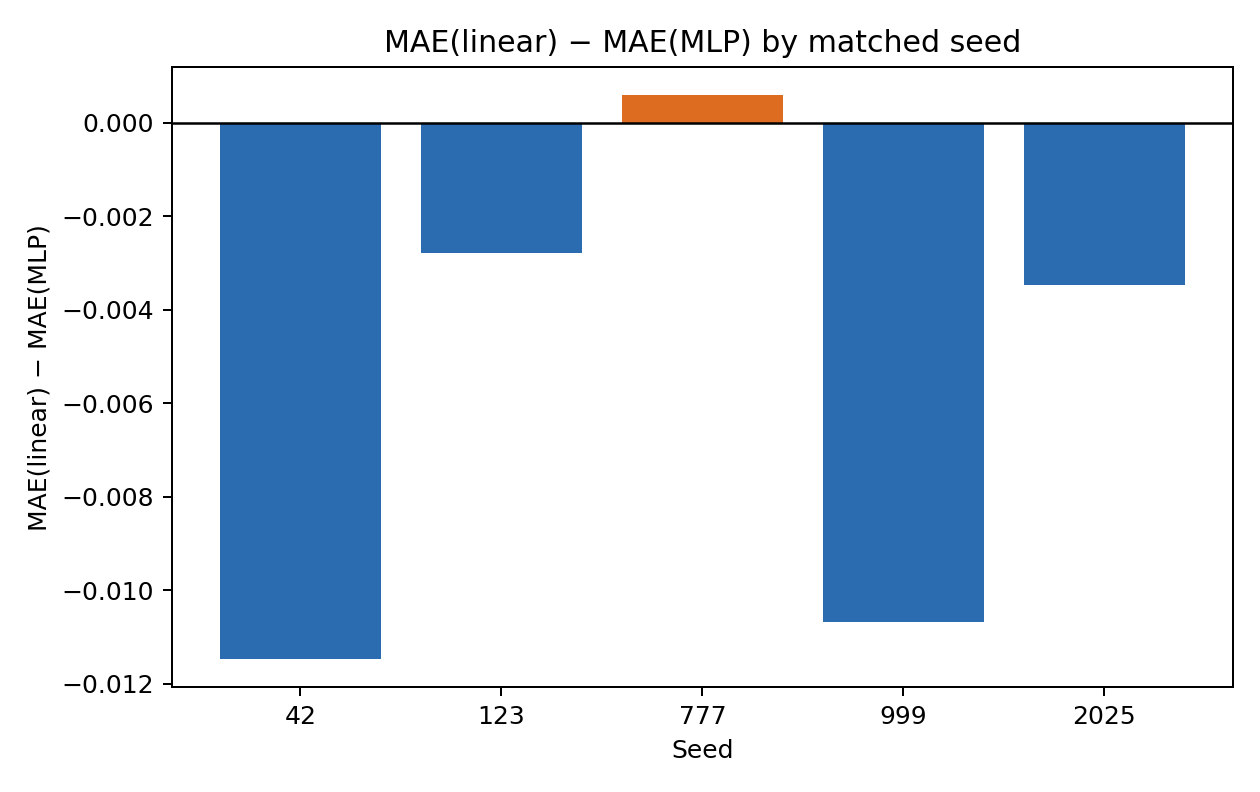

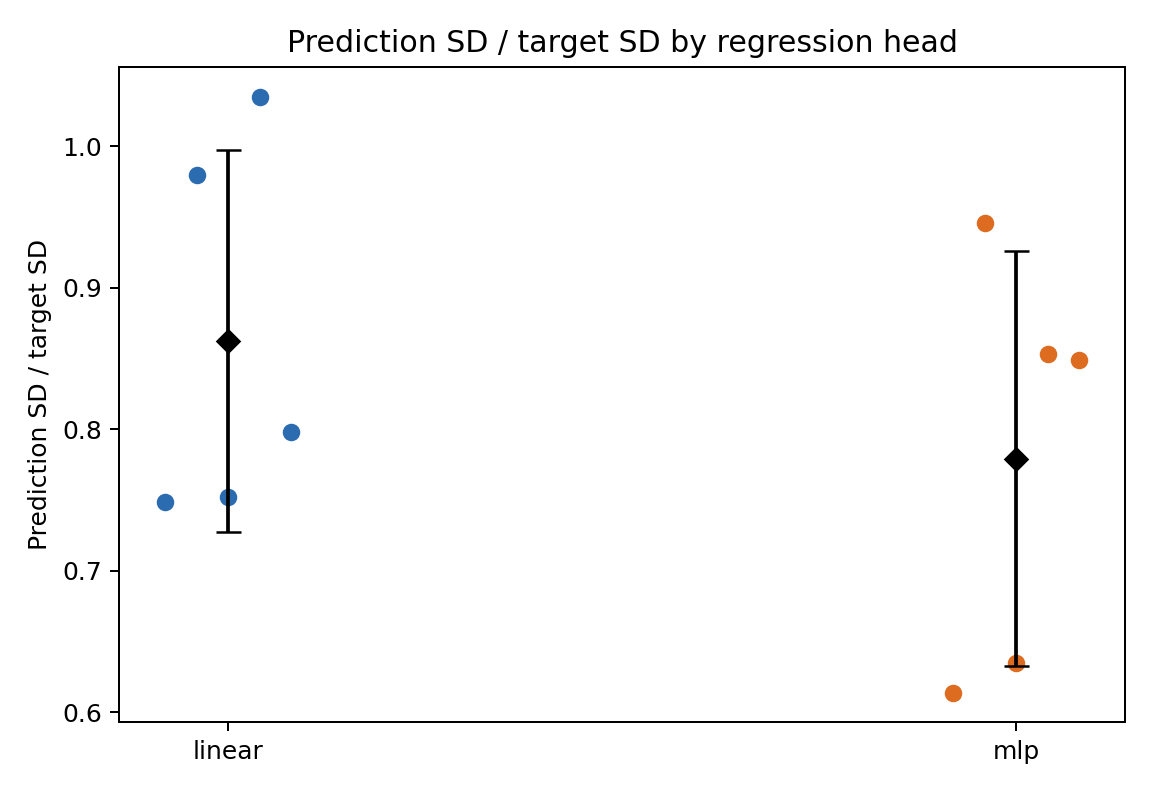

In [17]:
show_figures([
    ("head", "test_mae_by_regression_head", "Five-seed MAE by regression head."),
    ("head", "paired_mae_difference_by_seed", "Linear-minus-MLP paired MAE by seed."),
    ("head", "prediction_std_ratio_by_head", "Prediction dispersion by head."),
], width=760)

### Quantitative result
Linear reaches MAE **0.055843**, RMSE
**0.071136**, and R² **0.627697**. MLP reaches
**0.061404**, **0.076820**, and
**0.571180**. Linear wins four of five seeds; seed 777 favors MLP.

### Interpretation and boundary
Extra head complexity does not improve generalization here, and linear
predictions have greater dispersion. Similar train-validation gaps do not
demonstrate MLP overfitting, and this result does not imply universal linear
superiority.

<div class="takeaway"><b>Meeting takeaway.</b> The simpler head is modestly
better; the pooled representation may already expose useful information
approximately linearly.</div>

<details><summary>What to say during the meeting</summary>
The linear head performs better in four of five matched seeds, but the effect
is modest and comparable to seed variability. It also preserves more
prediction dispersion. This suggests that adding a shallow nonlinear mapping
does not recover missing information. We should not call this a universal
advantage for linear models.
</details>

# 12 — Graph-Pooling Ablation

### Scientific question
Does concatenating maximum node embeddings with the graph mean improve
readout?

### Why it matters and controlled protocol
Five exact EvolveGCN-H U750 Top1000 pairs hold all settings fixed except mean
versus mean+max graph pooling and the required linear-head input width.

In [18]:
pooling = read_csv("pooling", "aggregated_results.csv")
show_table(pooling, ["graph_pooling","seed_count","mean_test_mae","sd_test_mae","mean_test_rmse","mean_test_r2","mean_prediction_sd_ratio","mean_repeated_prediction_fraction"], precision=5, caption="Controlled graph-pooling result")

graph_pooling,seed_count,mean_test_mae,sd_test_mae,mean_test_rmse,mean_test_r2,mean_prediction_sd_ratio,mean_repeated_prediction_fraction
mean,5,0.05584,0.00875,0.07114,0.62770,0.86246,0.00000
mean_max,5,0.08097,0.01015,0.10617,0.16555,0.86348,0.00000


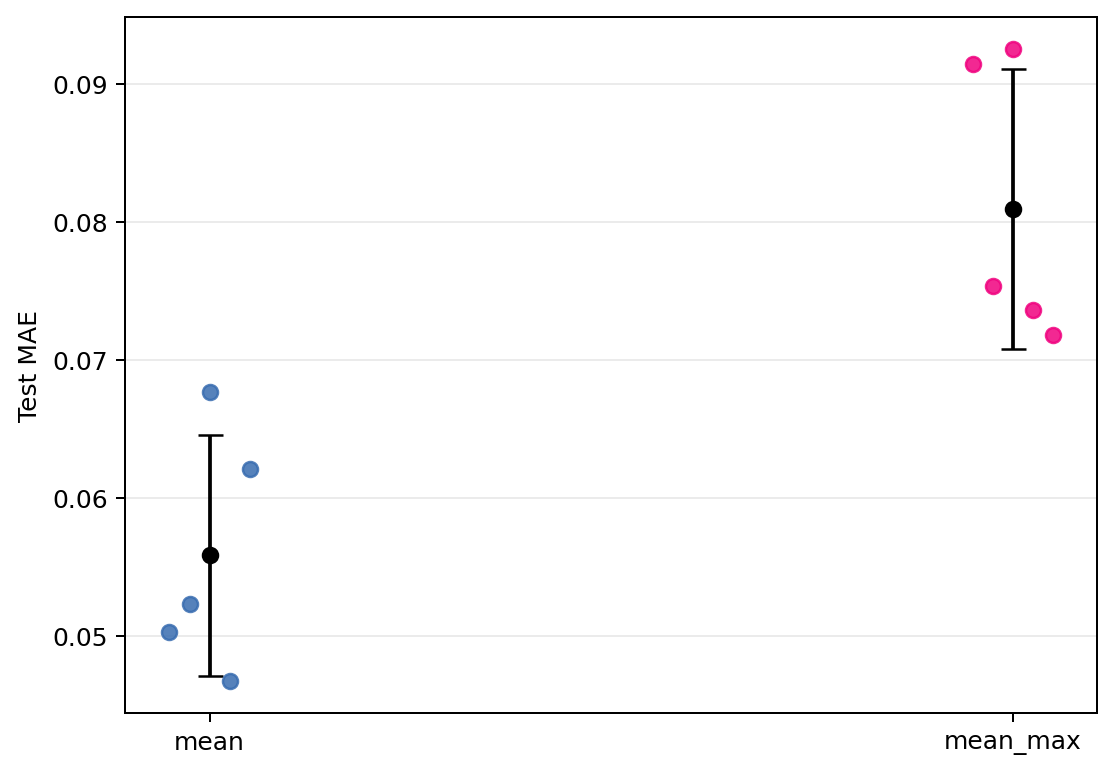

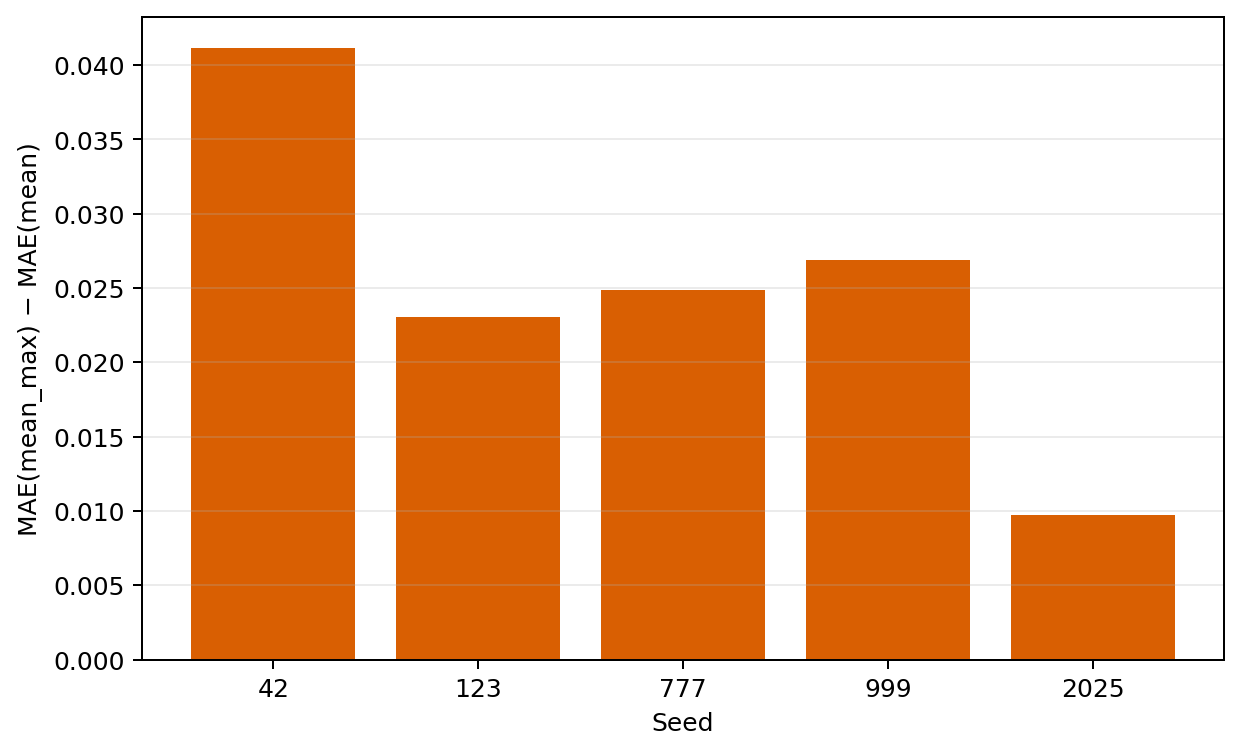

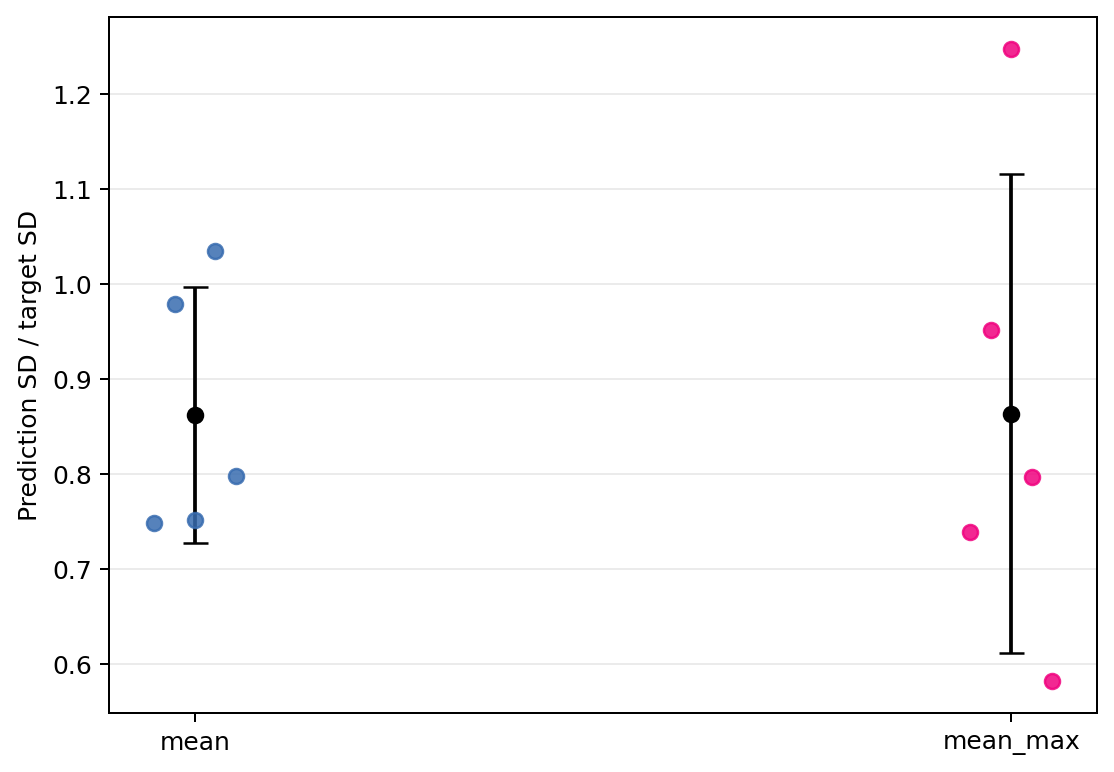

In [19]:
show_figures([
    ("pooling", "test_mae_by_graph_pooling", "Five-seed MAE by graph pooling."),
    ("pooling", "paired_mae_difference_by_seed", "Mean+max-minus-mean paired MAE."),
    ("pooling", "prediction_std_ratio_by_graph_pooling", "Prediction dispersion by graph pooling."),
], width=760)

### Quantitative result
Mean pooling achieves MAE **0.055843**, RMSE
**0.071136**, and R² **0.627697**. Mean+max reaches
**0.080973**, **0.106170**, and
**0.165548**. Mean wins all five seeds. SD ratios remain nearly
identical and neither method repeats predictions.

### Interpretation and boundary
Direct maximum concatenation worsens error without changing aggregate
dispersion, suggesting that raw extrema add unstable or poorly usable
information. This does not test attention or other adaptive readouts.

<div class="takeaway"><b>Meeting takeaway.</b> Naïve mean+max pooling is
clearly worse; distribution-preserving readout remains the open architectural
question.</div>

<details><summary>What to say during the meeting</summary>
This is the strongest negative architectural result. Mean+max is worse in
every matched seed and loses substantial R², even though prediction dispersion
barely changes. So the issue is not simply that mean pooling discards the
largest activation. Learned attention or richer distributional readout remains
untested.
</details>

# 13 — Secondary Temporal-Pooling Context

<div class="caveat"><b>Scope note.</b> A dedicated finalized temporal-pooling
report is not included in the current notebook; temporal pooling remains
separated from the completed primary ablations. No comparison is reconstructed
from unrelated experiments.</div>

# 14 — Cross-Experiment Synthesis

In [20]:
synthesis = pd.DataFrame([
    ("More universes improve learning", "Endpoint errors improve", "Intermediate values are non-monotonic", "Useful but insufficient", "Optimal data scale/cost"),
    ("More halos provide useful information", "Evolve improves at every step", "Static remains flat", "Model-dependent support", "Why Static cannot exploit added nodes"),
    ("Normalization improves optimization", "None", "None wins every matched comparison", "Rejected for sample-local minmax/zscore", "Global/train-fitted alternatives"),
    ("Denser graphs improve performance", "Some cell-specific gains", "No consistent k winner", "Not supported generally", "Other topology/readout choices"),
    ("Larger width improves capacity", "Occasional Evolve gains", "h64 inconsistent; Static mostly worse", "Not supported generally", "Different encoders/capacity regimes"),
    ("Nonlinear head improves mapping", "One MLP seed win", "Linear wins 4/5", "Not supported under tested head", "Other head families"),
    ("Mean+max preserves useful extrema", "Dispersion unchanged", "Error worsens in all seeds", "Rejected for direct concatenation", "Adaptive/distributional pooling"),
], columns=["Hypothesis","Evidence","Evidence against","Conclusion","Remaining uncertainty"])
show_table(synthesis, caption="Scientific synthesis across controlled analyses")

Hypothesis,Evidence,Evidence against,Conclusion,Remaining uncertainty
More universes improve learning,Endpoint errors improve,Intermediate values are non-monotonic,Useful but insufficient,Optimal data scale/cost
More halos provide useful information,Evolve improves at every step,Static remains flat,Model-dependent support,Why Static cannot exploit added nodes
Normalization improves optimization,None,None wins every matched comparison,Rejected for sample-local minmax/zscore,Global/train-fitted alternatives
Denser graphs improve performance,Some cell-specific gains,No consistent k winner,Not supported generally,Other topology/readout choices
Larger width improves capacity,Occasional Evolve gains,h64 inconsistent; Static mostly worse,Not supported generally,Different encoders/capacity regimes
Nonlinear head improves mapping,One MLP seed win,Linear wins 4/5,Not supported under tested head,Other head families
Mean+max preserves useful extrema,Dispersion unchanged,Error worsens in all seeds,Rejected for direct concatenation,Adaptive/distributional pooling


Prediction compression is reduced by preserving absolute scales, retaining
more halos for Evolve, and using the simpler head in the U750 protocol. It is
not eliminated, and no elementary hyperparameter explains the full gap.

# 15 — Controlled Results Versus Historical Best Runs

In [21]:
controlled = pd.concat([
    read_csv("topn", "aggregated_results.csv").assign(Experiment="Top-N")[["Experiment","model","top_n","seed_count","mean_test_mae","sd_test_mae"]],
    read_csv("normalization", "aggregated_results.csv").assign(Experiment="Normalization")[["Experiment","model","normalization","seed_count","mean_test_mae","sd_test_mae"]].rename(columns={"normalization":"top_n"}),
], ignore_index=True)
controlled = controlled.rename(columns={"model":"Model","top_n":"Best/Cell","seed_count":"Seeds","mean_test_mae":"Mean MAE","sd_test_mae":"SD MAE"})
show_table(controlled, precision=5, caption="Table A — Controlled multi-seed cells (not a cross-protocol leaderboard)")

norm_seed = read_csv("normalization", "seed_level_results.csv")
head_seed = read_csv("head", "seed_level_results.csv")
best_static = norm_seed[norm_seed["model"]=="Static GCN"].sort_values("test_mae").iloc[0]
best_evolve_norm = norm_seed[norm_seed["model"]=="EvolveGCN-H"].sort_values("test_mae").iloc[0]
best_evolve_head = head_seed.sort_values("test_mae").iloc[0]
best_evolve = best_evolve_norm if best_evolve_norm["test_mae"] <= best_evolve_head["test_mae"] else best_evolve_head
if "normalization" in best_evolve.index:
    evolve_protocol = f"U500 Top500 {best_evolve['normalization']} normalization"
else:
    evolve_protocol = f"U750 Top1000 {best_evolve['head_type']} head"
historical = pd.DataFrame([
    {"Model":"Static GCN","Exact protocol":f"U500 Top500 {best_static['normalization']} normalization","Seed":int(best_static["seed"]),"MAE":best_static["test_mae"],"Status":"Single seed","Qualification":"Not equivalent to a multi-seed mean"},
    {"Model":"EvolveGCN-H","Exact protocol":evolve_protocol,"Seed":int(best_evolve["seed"]),"MAE":best_evolve["test_mae"],"Status":"Single seed","Qualification":"Not equivalent to a multi-seed mean"},
])
show_table(historical, precision=6, caption="Table B — Historical best verified individual runs, clearly separated")

Experiment,Model,Best/Cell,Seeds,Mean MAE,SD MAE
Top-N,EvolveGCN-H,100,3,0.09696,0.00949
Top-N,EvolveGCN-H,200,3,0.09217,0.00833
Top-N,EvolveGCN-H,500,3,0.08617,0.00426
Top-N,Static GCN,100,3,0.09626,0.00834
Top-N,Static GCN,200,3,0.09698,0.00984
Top-N,Static GCN,500,3,0.09604,0.00892
Normalization,EvolveGCN-H,none,5,0.06580,0.00492
Normalization,EvolveGCN-H,minmax,5,0.08500,0.00443
Normalization,EvolveGCN-H,zscore,5,0.09455,0.00651
Normalization,Static GCN,none,5,0.04530,0.00373


Model,Exact protocol,Seed,MAE,Status,Qualification
Static GCN,U500 Top500 none normalization,123,0.042267,Single seed,Not equivalent to a multi-seed mean
EvolveGCN-H,U750 Top1000 linear head,999,0.046755,Single seed,Not equivalent to a multi-seed mean


# 16 — What the Tree Baselines Teach Us

Subject to the baseline audit's remaining raw-column provenance confirmation,
Random Forest and Gradient Boosting results indicate that explicit
distributional summaries contain strong $\Omega_m$ signal. This shifts the
diagnosis away from an impossible target and toward how the tested graph
encoders and readouts preserve mass-distribution and phase-space information.

The tested graph architectures did not outperform the strongest
summary-feature baselines under the evaluated protocols. Graph structure is
not automatically superior to well-chosen distributional summaries, and this
negative result is scientifically informative.

# 17 — Final Answer to the Research Question

The repository evidence indicates that $\Omega_m$ is learnable from
CAMELS-SIMBA halo catalogues. Absolute feature scales and a broader halo
population carry useful information. Sample-local normalization removes
useful signal under the tested implementation. Increasing graph density or
hidden width has small, inconsistent effects. A linear head modestly
outperforms the tested MLP, while direct mean+max pooling clearly degrades
generalization.

Prediction compression remains central: some choices improve dispersion, but
the tested GNN readouts still do not preserve all informative distributional
structure. The result applies to these architectures and protocols; it does
not imply that all GNNs would behave similarly.

# 18 — Limitations

In [22]:
limitations = pd.DataFrame({
    "Limitation": [
        "Finite seed counts (three or five depending on analysis)",
        "Canonical protocols differ between experiments",
        "Sample-local normalization changes between-universe information",
        "Top-N rebuilding changes kNN topology",
        "Selected halo nesting is not byte-proven",
        "Wall time and peak-memory measurements are incomplete",
        "Cross-model comparisons are descriptive",
        "Single-seed best runs are not multi-seed means",
        "Attention pooling remains untested",
        "Tree baselines use explicit distributional summaries",
    ]
})
show_table(limitations, caption="Boundaries on interpretation")

Limitation
Finite seed counts (three or five depending on analysis)
Canonical protocols differ between experiments
Sample-local normalization changes between-universe information
Top-N rebuilding changes kNN topology
Selected halo nesting is not byte-proven
Wall time and peak-memory measurements are incomplete
Cross-model comparisons are descriptive
Single-seed best runs are not multi-seed means
Attention pooling remains untested
Tree baselines use explicit distributional summaries


# 19 — Next Scientific Decision

### Complete

Universe scaling; Top-N scaling; normalization; k × hidden dimension;
regression head; mean versus mean+max graph pooling.

### Still unknown

Learned attention pooling, quantile- or mass-aware readout,
distribution-preserving graph summaries, careful fusion of explicit
mass-distribution features, and fully identical Static-versus-temporal
protocols.

<div class="takeaway"><b>One recommended next direction.</b> Investigate an
adaptive or distribution-preserving graph readout rather than repeating basic
width, k, normalization, or mean+max experiments. This report recommends a
scientific direction; it does not launch training.</div>

# 20 — Meeting Summary

In [23]:
meeting = pd.DataFrame({
    "Strongest findings": [
        "Absolute feature scales matter under the tested preprocessing",
        "More halos consistently help EvolveGCN-H",
        "A simple linear head modestly improves the U750 protocol",
    ],
    "Important negative results": [
        "k and hidden width do not consistently improve performance",
        "Static GCN does not exploit the larger Top-N population",
        "Mean+max pooling is worse than mean in every matched seed",
    ],
    "Remaining uncertainties": [
        "Best adaptive or distribution-preserving graph readout",
        "Fully controlled temporal-versus-static contribution",
        "Quantified performance-versus-memory/time trade-off",
    ],
})
show_table(meeting, caption="Final presentation page")

Strongest findings,Important negative results,Remaining uncertainties
Absolute feature scales matter under the tested preprocessing,k and hidden width do not consistently improve performance,Best adaptive or distribution-preserving graph readout
More halos consistently help EvolveGCN-H,Static GCN does not exploit the larger Top-N population,Fully controlled temporal-versus-static contribution
A simple linear head modestly improves the U750 protocol,Mean+max pooling is worse than mean in every matched seed,Quantified performance-versus-memory/time trade-off


### Questions for supervisor discussion

1. Is the current evidence sufficient to close the core experimental phase?
2. Should learned attention pooling be final experimentation or future work?
3. Which controlled results should lead the thesis Results chapter?
4. Should the qualified summary-feature baseline become a central thesis
   contribution after its final provenance confirmation?

# Appendix — Reproducibility and Source Map

In [24]:
source_map = pd.read_csv(ROOT / "reports/meeting/10_final_experiment_report_source_map.csv")
show_table(source_map, caption="Displayed-result source map")
display(Markdown(
    "**Repository state**  \n"
    "- Branch: `thesis-controlled-scaling`  \n"
    "- Commit used to generate notebook: `56c348cb458419e630eefb62e2f4b2112dbaa348`  \n"
    "- Date generated: `2026-07-30`  \n"
    "- No training occurred.  \n"
    "- No graph dataset or checkpoint was loaded.  \n"
    "- Every displayed scientific result came from a finalized package, except the explicitly qualified baseline context."
))

notebook_section,source_analysis_package,source_csv_or_markdown,displayed_figure_path,analysis_specification,validator_status
Baseline context,reports/experiment_registry,baseline_validation_audit.md; experiments/summary_features_500u_none_top500_matched_seed42/metrics.json,—,—,Qualified audit; one confirmation remains
Universe-count scaling,reports/analysis/controlled_static_vs_evolvegcn_universe_scaling_top100,aggregated_results.csv,figures/test_mae_vs_universes.png; figures/prediction_std_ratio_vs_universes.png,configs/analysis_reports/controlled_static_vs_evolvegcn_universe_scaling_top100.json,PASS
Top-N scaling,reports/analysis/controlled_static_vs_evolvegcn_topn_halo_scaling_500u,tables/main_results_table.csv; tables/computational_scaling.csv,figures/test_mae_vs_topn.png; figures/prediction_std_ratio_vs_topn.png; figures/repeated_prediction_fraction_vs_topn.png,configs/analysis_reports/controlled_static_vs_evolvegcn_topn_halo_scaling_500u.json,PASS
Normalization,reports/analysis/controlled_static_vs_evolvegcn_normalization_ablation_500u_top500,aggregated_results.csv,figures/test_mae_vs_normalization.png; figures/prediction_std_ratio_vs_normalization.png; figures/repeated_prediction_fraction_vs_normalization.png,configs/analysis_reports/controlled_static_vs_evolvegcn_normalization_ablation_500u_top500.json,PASS
k × hidden dimension,reports/analysis/controlled_knn_by_hidden_dim_factorial_500u_top100,aggregated_results.csv,figures/test_mae_vs_k_by_hidden_dim.png; figures/paired_width_mae_difference_vs_k.png; figures/prediction_std_ratio_vs_k_and_width.png,configs/analysis_reports/controlled_knn_by_hidden_dim_factorial_500u_top100.json,PASS
Regression head,reports/analysis/controlled_evolvegcn_regression_head_ablation_750u_top1000,aggregated_results.csv,figures/test_mae_by_regression_head.png; figures/paired_mae_difference_by_seed.png; figures/prediction_std_ratio_by_head.png,configs/analysis_reports/controlled_evolvegcn_regression_head_ablation_750u_top1000.json,PASS
Graph pooling,reports/analysis/controlled_evolvegcn_graph_pooling_ablation_750u_top1000,aggregated_results.csv,figures/test_mae_by_graph_pooling.png; figures/paired_mae_difference_by_seed.png; figures/prediction_std_ratio_by_graph_pooling.png,configs/analysis_reports/controlled_evolvegcn_graph_pooling_ablation_750u_top1000.json,PASS
Cross-experiment synthesis,All packages above,aggregated_results.csv; seed_level_results.csv,—,Specifications above,PASS


**Repository state**  
- Branch: `thesis-controlled-scaling`  
- Commit used to generate notebook: `56c348cb458419e630eefb62e2f4b2112dbaa348`  
- Date generated: `2026-07-30`  
- No training occurred.  
- No graph dataset or checkpoint was loaded.  
- Every displayed scientific result came from a finalized package, except the explicitly qualified baseline context.

In [25]:
source_requirements = []
for key, package in PACKAGES.items():
    source_requirements.append({
        "Package": PACKAGE_NAMES[key],
        "Manifest": (package / "analysis_manifest.json").is_file(),
        "Scientific summary": (package / "scientific_summary.md").is_file(),
    })
checks = pd.DataFrame(source_requirements)
if not checks[["Manifest","Scientific summary"]].all().all():
    raise RuntimeError("A finalized source package is incomplete.")
show_table(checks, caption="Finalized source-package checks")

Package,Manifest,Scientific summary
controlled_static_vs_evolvegcn_universe_scaling_top100,True,True
controlled_static_vs_evolvegcn_topn_halo_scaling_500u,True,True
controlled_static_vs_evolvegcn_normalization_ablation_500u_top500,True,True
controlled_static_vs_evolvegcn_knn_ablation_500u_top100_h64,True,True
controlled_knn_by_hidden_dim_factorial_500u_top100,True,True
controlled_evolvegcn_regression_head_ablation_750u_top1000,True,True
controlled_evolvegcn_graph_pooling_ablation_750u_top1000,True,True
